# Conv model

The structure is simple:

- Input: image with 3 channels

- One convolutional layer: represented by the first adapter

- One recurrent convolutional module: represented the first layer

- Global majority pooling: each channel in the convolutional block is converted to a single scalar, by taking the majority. This is an adapter.

- Recurrent fully connected: as usual

- Wout: as usual

## Notes:

Layers communicate in both directions. This architecture still avoids a conv2dTranspose (i still have to test it).

## Imports

In [9]:
import sys
print(sys.path)
import darnax
print(darnax.__file__)

['/Users/michelangelonardi/Desktop/Università/Master/Bocconi Master/Tesi/darnax/src', '/opt/anaconda3/envs/brainAI/lib/python311.zip', '/opt/anaconda3/envs/brainAI/lib/python3.11', '/opt/anaconda3/envs/brainAI/lib/python3.11/lib-dynload', '', '/opt/anaconda3/envs/brainAI/lib/python3.11/site-packages', '/Users/michelangelonardi/Desktop/Università/Master/Bocconi Master/Tesi/darnax/src']
/Users/michelangelonardi/Desktop/Università/Master/Bocconi Master/Tesi/darnax/src/darnax/__init__.py


In [10]:
import sys
sys.path.insert(0, '/Users/michelangelonardi/Desktop/Università/Master/Bocconi Master/Tesi/darnax/src')

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity

In [12]:
import jax
from darnax.modules.conv.conv import Conv2D, Conv2DRecurrentDiscrete
from darnax.modules.conv.pooling import GlobalUnpooling, GlobalMajorityPooling
from darnax.modules.fully_connected import FullyConnected, FrozenRescaledFullyConnected
from darnax.modules.recurrent import RecurrentDiscrete
from darnax.modules.input_output import OutputLayer

In [13]:
from darnax.layer_maps.sparse import LayerMap
from darnax.states.sequential import SequentialState
from darnax.orchestrators.sequential import SequentialOrchestrator

In [14]:
def run_dynamics(x, y, N_CHANNELS=64, INPUT_KERNEL_SIZE=7, RECUR_KERNEL_SIZE=7, j_d_conv=0.9, j_d_fc=0.9, strength_pool=1.0, strength_unpool=1.0, strength_wout=1.0, strength_wback=1.0,
                 n_warmup=1, n_clamped=5, n_free=5, seed=42):
    """
    Build a network with given parameters, run dynamics, return states_history.
    """
    keys_test = jax.random.split(jax.random.PRNGKey(seed), 5)
    
    _input_to_hidden = Conv2D(
        in_channels=3, out_channels=N_CHANNELS, kernel_size=INPUT_KERNEL_SIZE,
        threshold=1.7, strength=1.0, key=keys_test[0], padding_mode='constant',
    )
    _recurrent_conv = Conv2DRecurrentDiscrete(
        channels=N_CHANNELS, kernel_size=RECUR_KERNEL_SIZE, groups=N_CHANNELS,
        j_d=j_d_conv, threshold=1.7, padding_mode="constant",
        key=keys_test[1], lr=1.0, weight_decay=0.0,
    )
    _pooling_forward = GlobalMajorityPooling(strength=strength_pool, axis=(1, 2))
    _unpooling_backward = GlobalUnpooling(strength=strength_unpool, axis=(1, 2))
    _recurrent = RecurrentDiscrete(
        features=N_CHANNELS, j_d=j_d_fc, threshold=1.7, key=keys_test[2],
    )
    _wout = FullyConnected(
        in_features=N_CHANNELS, out_features=10,
        strength=strength_wout, threshold=1.7, key=keys_test[3],
    )
    _wback = FrozenRescaledFullyConnected(
        in_features=10, out_features=N_CHANNELS,
        strength=strength_wback, threshold=0.0, key=keys_test[4],
    )
    
    _layer_map = LayerMap.from_dict({
        1: {0: _input_to_hidden, 1: _recurrent_conv, 2: _unpooling_backward},
        2: {1: _pooling_forward, 2: _recurrent, 3: _wback},
        3: {2: _wout, 3: OutputLayer()},
    })
    _orchestrator = SequentialOrchestrator(layers=_layer_map)
    
    _state = SequentialState([(32, 32, 3), (32, 32, N_CHANNELS), (N_CHANNELS,), (10,)])
    _state = _state.init(x, y)
    
    _key, _fk = jax.random.split(jax.random.PRNGKey(seed + 1))
    _history = []
    
    for _ in range(n_warmup):
        _state, _fk = _orchestrator.step(_state, rng=_fk, filter_messages="inference")
        _history.append(_state)
    for _ in range(n_clamped):
        _state, _fk = _orchestrator.step(_state, rng=_fk, filter_messages="all")
        _history.append(_state)
    for _ in range(n_free):
        _state, _fk = _orchestrator.step(_state, rng=_fk, filter_messages="inference")
        _history.append(_state)
    
    return _history

## Importing the dataset (CIFAR)

In [15]:
from darnax.datasets.classification.cifar10 import Cifar10

data = Cifar10(
    batch_size=32,
    linear_projection=None,
    label_mode="pm1",
    x_transform="identity",
)

key = jax.random.PRNGKey(0)
key, data_key = jax.random.split(key)

data.build(key=data_key)

Array([2566685366, 2716172981], dtype=uint32)

In [16]:
# In order to do something:
# first we take a batch of data and we standardize it

x, y = next(iter(data))
print(f"Data shape: x={x.shape}, y={y.shape}")
print(f"Expected: x=(batch, 32, 32, 3), got x={x.shape}")

# If flattened, reshape it back
if x.ndim == 2:
    x = x.reshape(x.shape[0], 32, 32, 3)
    print(f"Reshaped x to: {x.shape}")

x = (x - x.mean()) / x.std()

Data shape: x=(32, 3072), y=(32, 10)
Expected: x=(batch, 32, 32, 3), got x=(32, 3072)
Reshaped x to: (32, 32, 32, 3)


In [17]:
def compute_cosine_similarity_matrix(states_history, layer_idx=1, batch_idx=None):
    
    n_timesteps = len(states_history)
    sim_matrix = np.zeros((n_timesteps, n_timesteps))
    
    # Only compute upper triangle (cosine similarity is symmetric)
    for i in range(n_timesteps):
        for j in range(i, n_timesteps):
            state_i = states_history[i].states[layer_idx]
            state_j = states_history[j].states[layer_idx]
            
            # Flatten both states to (batch, features)
            s_i = state_i.reshape(state_i.shape[0], -1)
            s_j = state_j.reshape(state_j.shape[0], -1)
            
            if batch_idx is not None:
                # Single image: cosine similarity for that image
                sim = cosine_similarity([s_i[batch_idx]], [s_j[batch_idx]])[0, 0]
                sim_matrix[i, j] = sim
                sim_matrix[j, i] = sim
            else:
                # All images: compute similarity for each, then average
                sim_list = []
                for b in range(s_i.shape[0]):
                    try:
                        sim = cosine_similarity([s_i[b]], [s_j[b]])[0, 0]
                        sim_list.append(sim)
                    except:
                        sim_list.append(np.nan)
                
                sim_value = np.nanmean(sim_list)
                sim_matrix[i, j] = sim_value
                sim_matrix[j, i] = sim_value
    
    return sim_matrix

In [18]:
def compute_neuron_flips(states_history, layer_idx=1, batch_idx=None, percentage=False):

    n_timesteps = len(states_history)
    flips = np.zeros(n_timesteps - 1)
    
    for t in range(n_timesteps - 1):
        state_t = states_history[t].states[layer_idx]
        state_t1 = states_history[t + 1].states[layer_idx]
        
        # Flatten to (batch, features)
        s_t = state_t.reshape(state_t.shape[0], -1)
        s_t1 = state_t1.reshape(state_t1.shape[0], -1)
        
        n_neurons = s_t.shape[1]
        
        if batch_idx is not None:
            flipped = np.sum(s_t[batch_idx] != s_t1[batch_idx])
            flips[t] = (flipped / n_neurons * 100) if percentage else flipped
        else:
            flip_list = []
            for b in range(s_t.shape[0]):
                flipped = np.sum(s_t[b] != s_t1[b])
                flip_list.append((flipped / n_neurons * 100) if percentage else flipped)
            flips[t] = np.mean(flip_list)
    
    return flips


def plot_neuron_flips(flips_dict, title="Neuron Flips Over Time", figsize=(10, 5), percentage=False):

    fig, ax = plt.subplots(figsize=figsize)
    
    if isinstance(flips_dict, dict):
        for label, flips in flips_dict.items():
            ax.plot(range(len(flips)), flips, marker='o', label=label, linewidth=2)
        ax.legend()
    else:
        ax.plot(range(len(flips_dict)), flips_dict, marker='o', linewidth=2, color='blue')
    
    ax.set_xlabel('Step', fontsize=12)
    ylabel = '% of Neurons Flipped' if percentage else 'Number of Neuron Flips'
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [35]:
def plot_correlation_row(corr_matrices, subtitles, suptitle="", figsize=(30, 7), vmin=0.3, vmax=1):
    """
    Plot a row of correlation matrices side by side.
    
    Parameters
    ----------
    corr_matrices : list of arrays
        List of correlation matrices to plot
    subtitles : list of str
        Subtitle for each plot
    suptitle : str
        Overall title for the figure
    """
    n = len(corr_matrices)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    
    for idx, (cm, subtitle) in enumerate(zip(corr_matrices, subtitles)):
        im = axes[idx].imshow(cm, cmap='coolwarm', aspect='auto', vmin=vmin, vmax=vmax)
        axes[idx].set_title(subtitle, fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Timestep', fontsize=8)
        axes[idx].set_ylabel('Timestep', fontsize=8)
        axes[idx].set_xticks(range(cm.shape[1]))
        axes[idx].set_yticks(range(cm.shape[0]))
    
    fig.colorbar(im, ax=axes, label='Correlation', shrink=0.8)
    fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## Parameter Sweep: J_d and Strength

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_99964/563077644.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


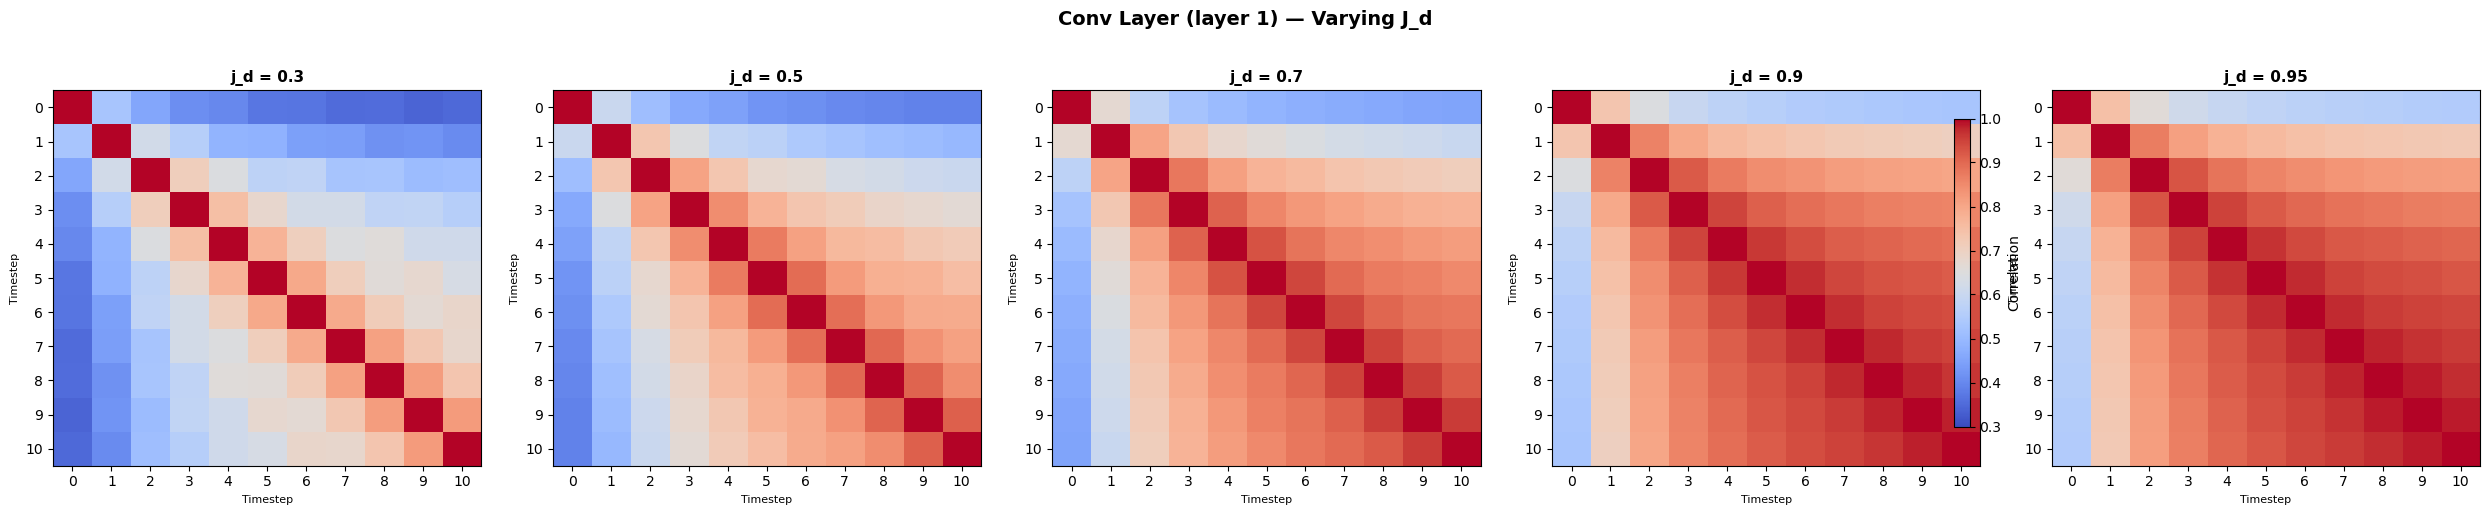

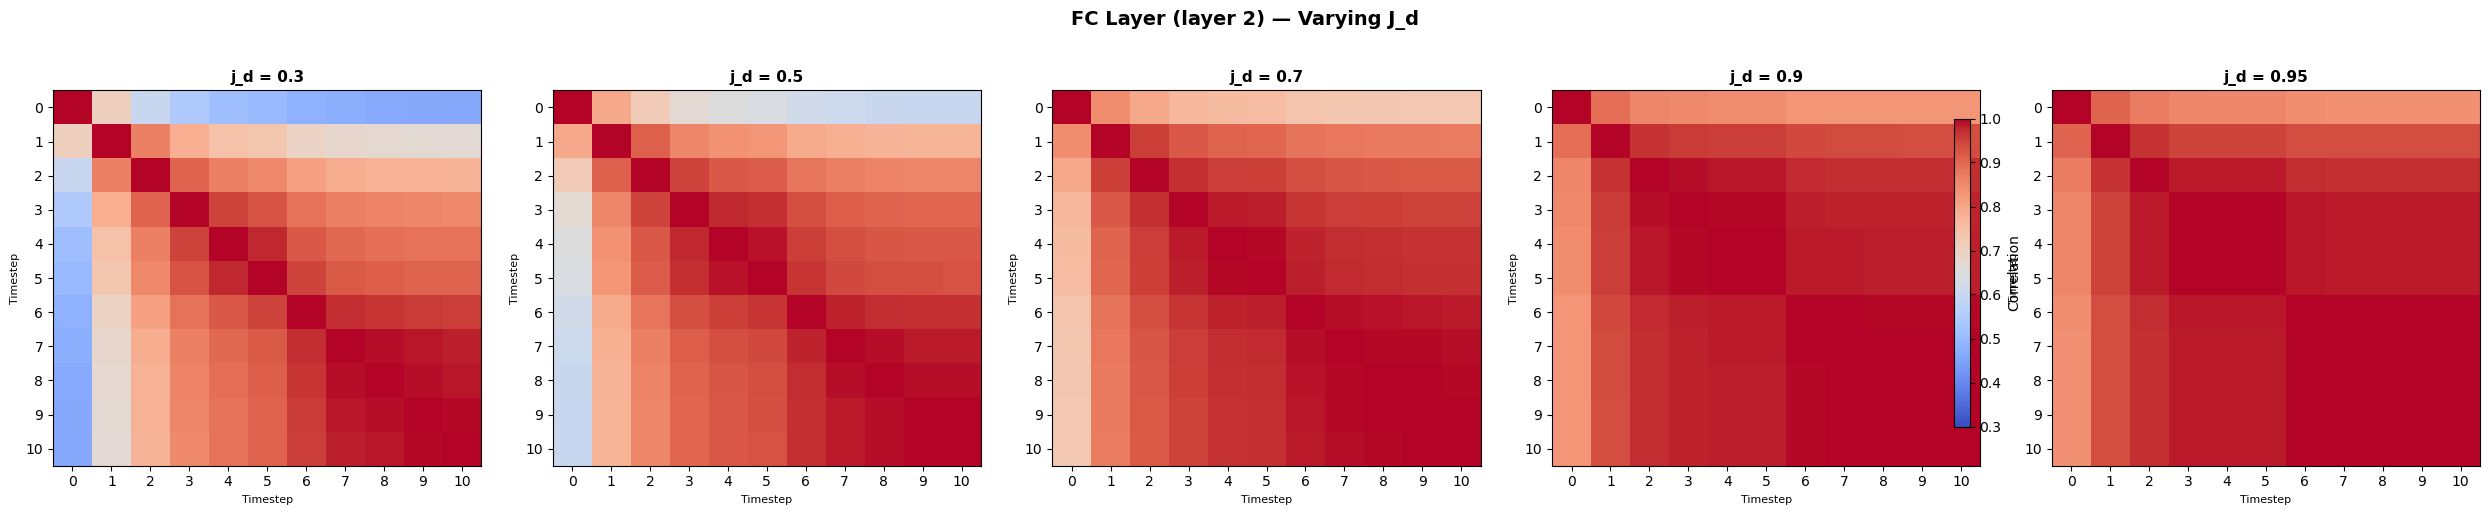

In [ ]:
# ---- Sweep over J_d ----
j_d_values = [0.3, 0.5, 0.7, 0.9, 0.95]

# Conv layer (layer 1)
corr_matrices_jd_l1 = []
for j_d in j_d_values:
    history = run_dynamics(x, y, j_d_conv=j_d, j_d_fc=j_d)
    cm = compute_cosine_similarity_matrix(history, layer_idx=1)
    corr_matrices_jd_l1.append(cm)

subtitles_jd = [f"j_d = {j}" for j in j_d_values]
plot_correlation_row(corr_matrices_jd_l1, subtitles_jd, suptitle="Conv Layer (layer 1) — Varying J_d")

# FC layer (layer 2)
corr_matrices_jd_l2 = []
for j_d in j_d_values:
    history = run_dynamics(x, y, j_d_conv=j_d, j_d_fc=j_d)
    cm = compute_cosine_similarity_matrix(history, layer_idx=2)
    corr_matrices_jd_l2.append(cm)

plot_correlation_row(corr_matrices_jd_l2, subtitles_jd, suptitle="FC Layer (layer 2) — Varying J_d")

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_99964/563077644.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


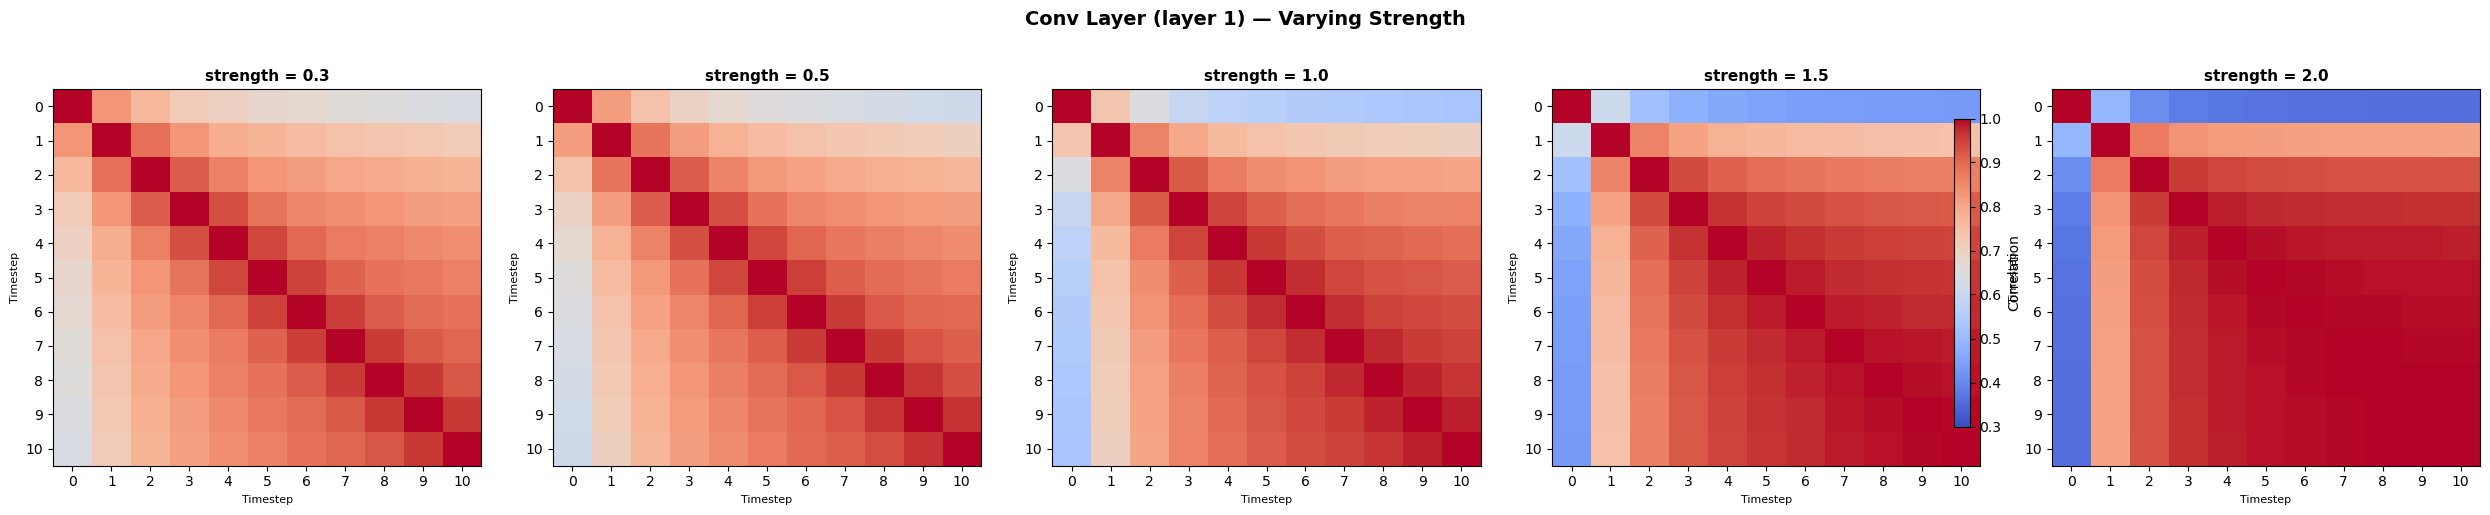

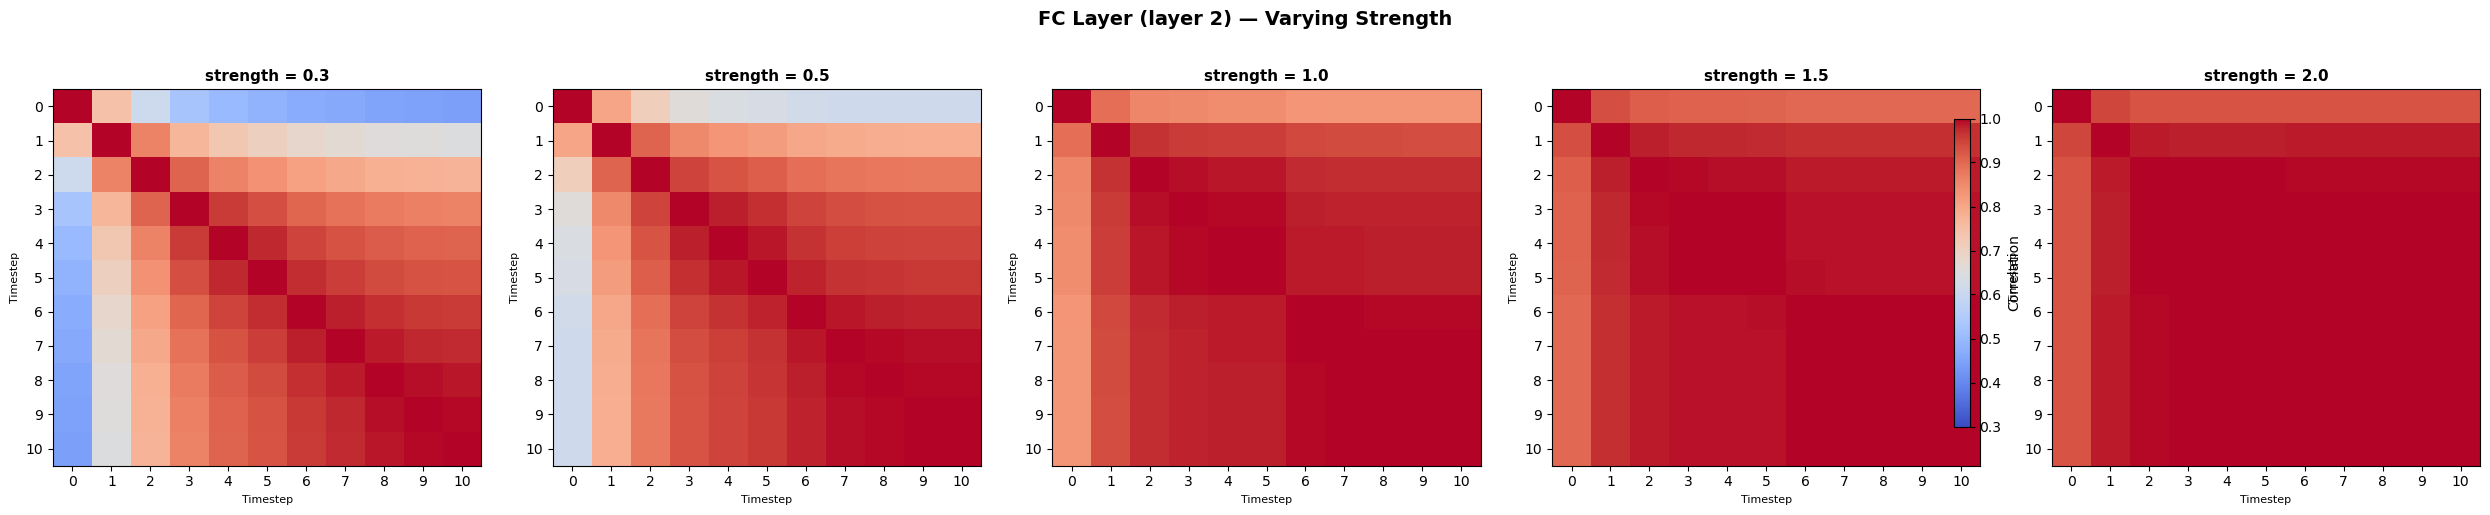

In [ ]:
# ---- Sweep over strength ----
strength_values = [0.3, 0.5, 1.0, 1.5, 2.0]

# Conv layer (layer 1)
corr_matrices_str_l1 = []
for s in strength_values:
    history = run_dynamics(x, y, strength_pool=s, strength_wout=s, strength_wback=s)
    cm = compute_cosine_similarity_matrix(history, layer_idx=1)
    corr_matrices_str_l1.append(cm)

subtitles_str = [f"strength = {s}" for s in strength_values]
plot_correlation_row(corr_matrices_str_l1, subtitles_str, suptitle="Conv Layer (layer 1) — Varying Strength")

# FC layer (layer 2)
corr_matrices_str_l2 = []
for s in strength_values:
    history = run_dynamics(x, y, strength_pool=s, strength_wout=s, strength_wback=s)
    cm = compute_cosine_similarity_matrix(history, layer_idx=2)
    corr_matrices_str_l2.append(cm)

plot_correlation_row(corr_matrices_str_l2, subtitles_str, suptitle="FC Layer (layer 2) — Varying Strength")

### Neuron Flips Sweep

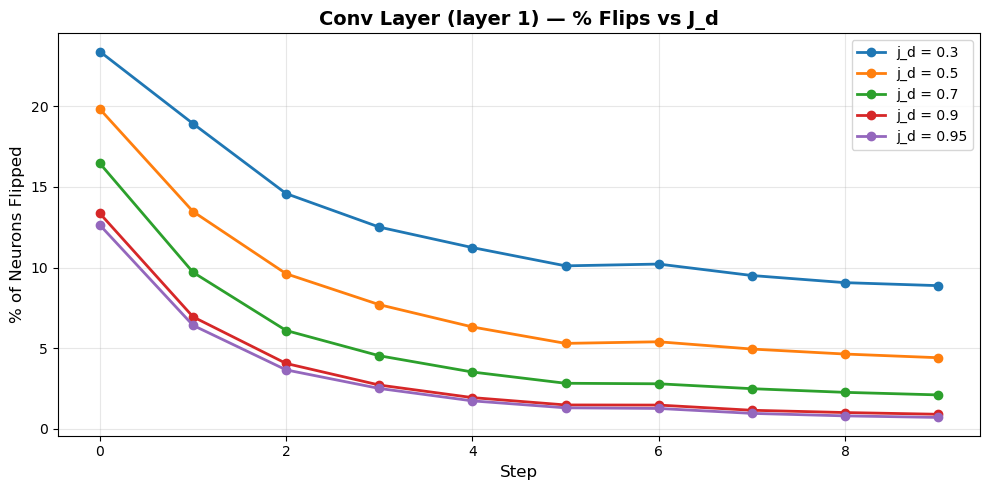

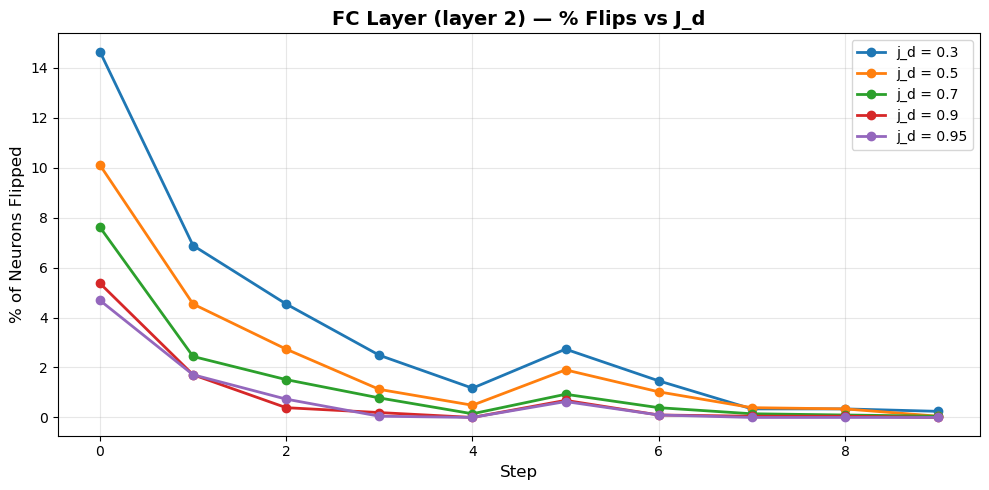

In [170]:
# ---- Neuron flips sweep over J_d ----
j_d_values = [0.3, 0.5, 0.7, 0.9, 0.95]

# Conv layer (layer 1)
flips_jd_l1 = {}
for j_d in j_d_values:
    history = run_dynamics(x, y, j_d_conv=j_d, j_d_fc=j_d)
    flips_jd_l1[f"j_d = {j_d}"] = compute_neuron_flips(history, layer_idx=1, percentage=True)

plot_neuron_flips(flips_jd_l1, title="Conv Layer (layer 1) — % Flips vs J_d", percentage=True)

# FC layer (layer 2)
flips_jd_l2 = {}
for j_d in j_d_values:
    history = run_dynamics(x, y, j_d_conv=j_d, j_d_fc=j_d)
    flips_jd_l2[f"j_d = {j_d}"] = compute_neuron_flips(history, layer_idx=2, percentage=True)

plot_neuron_flips(flips_jd_l2, title="FC Layer (layer 2) — % Flips vs J_d", percentage=True)

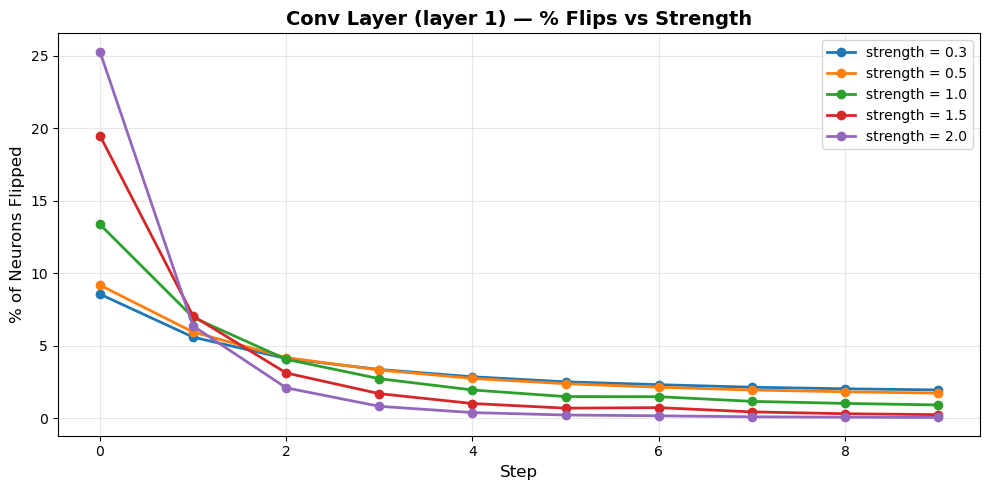

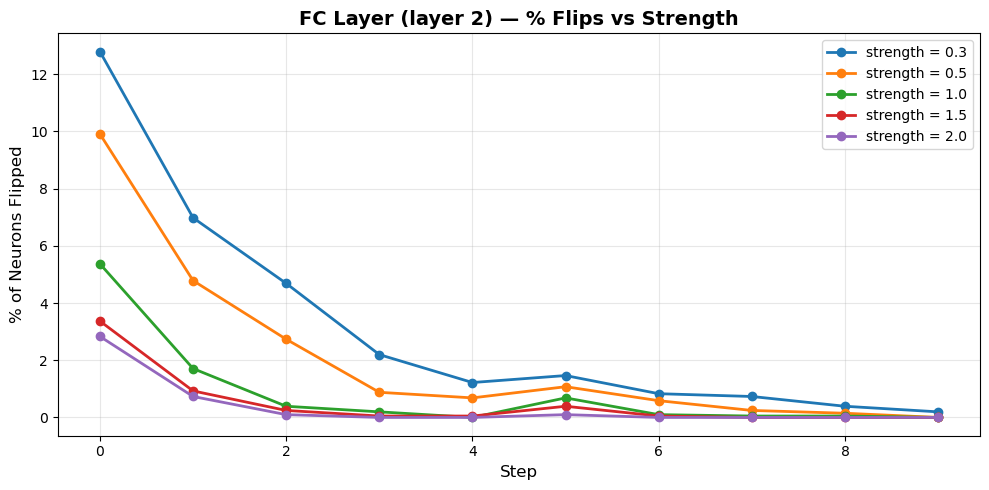

In [171]:
# ---- Neuron flips sweep over Strength ----
strength_values = [0.3, 0.5, 1.0, 1.5, 2.0]

# Conv layer (layer 1)
flips_str_l1 = {}
for s in strength_values:
    history = run_dynamics(x, y, strength_pool=s, strength_wout=s, strength_wback=s)
    flips_str_l1[f"strength = {s}"] = compute_neuron_flips(history, layer_idx=1, percentage=True)

plot_neuron_flips(flips_str_l1, title="Conv Layer (layer 1) — % Flips vs Strength", percentage=True)

# FC layer (layer 2)
flips_str_l2 = {}
for s in strength_values:
    history = run_dynamics(x, y, strength_pool=s, strength_wout=s, strength_wback=s)
    flips_str_l2[f"strength = {s}"] = compute_neuron_flips(history, layer_idx=2, percentage=True)

plot_neuron_flips(flips_str_l2, title="FC Layer (layer 2) — % Flips vs Strength", percentage=True)

## Individual Strength Parameter Sweep
Vary each strength independently while keeping all others at 1.0.

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_52318/2733256664.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


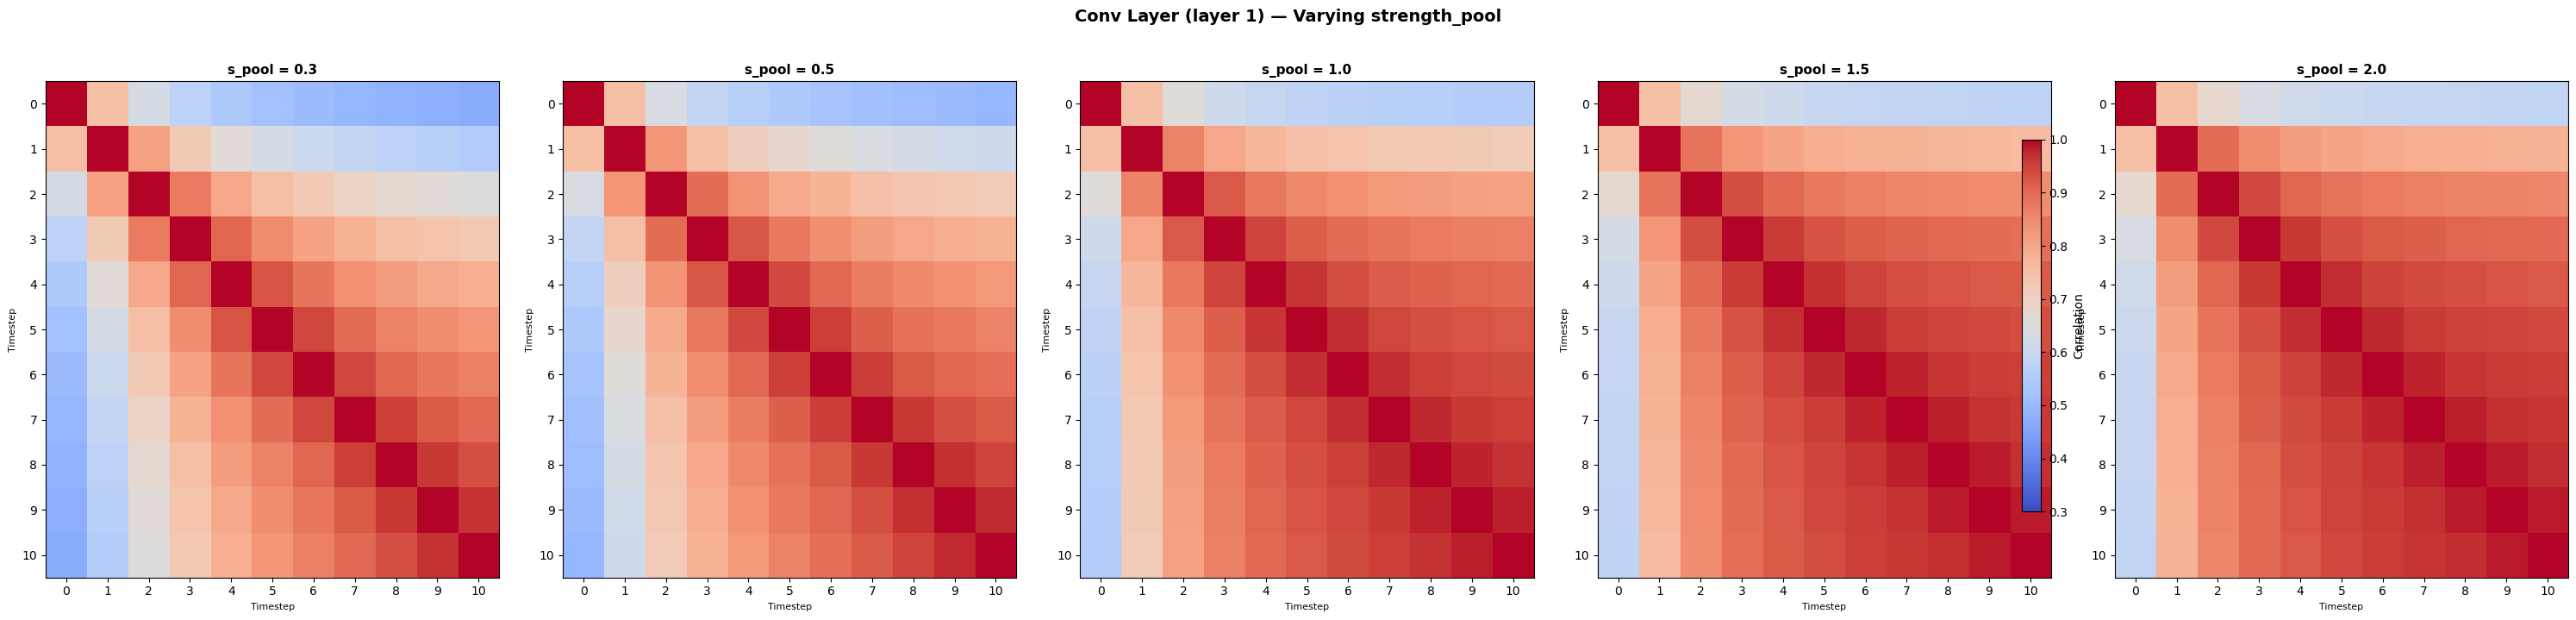

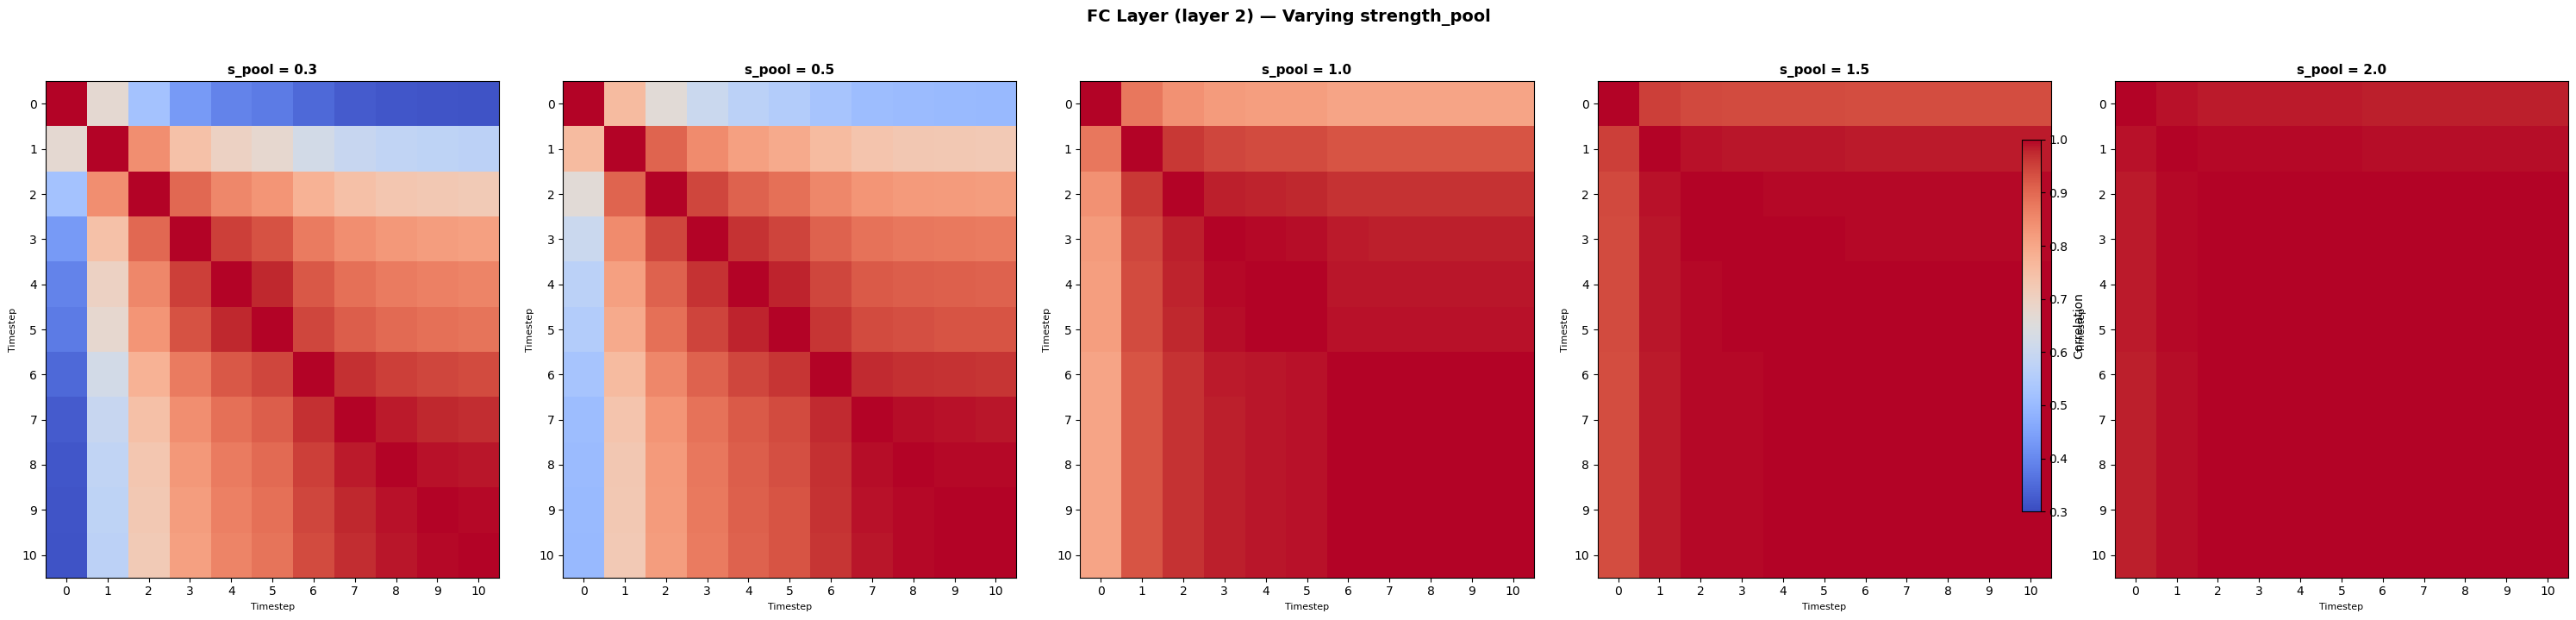

In [36]:
# ---- Sweep over strength_pool (only) ----
strength_values = [0.3, 0.5, 1.0, 1.5, 2.0]
subtitles = [f"s_pool = {s}" for s in strength_values]

corr_l1, corr_l2 = [], []
for s in strength_values:
    history = run_dynamics(x, y, strength_pool=s)
    corr_l1.append(compute_cosine_similarity_matrix(history, layer_idx=1))
    corr_l2.append(compute_cosine_similarity_matrix(history, layer_idx=2))

plot_correlation_row(corr_l1, subtitles, suptitle="Conv Layer (layer 1) — Varying strength_pool")
plot_correlation_row(corr_l2, subtitles, suptitle="FC Layer (layer 2) — Varying strength_pool")

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_52318/2733256664.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


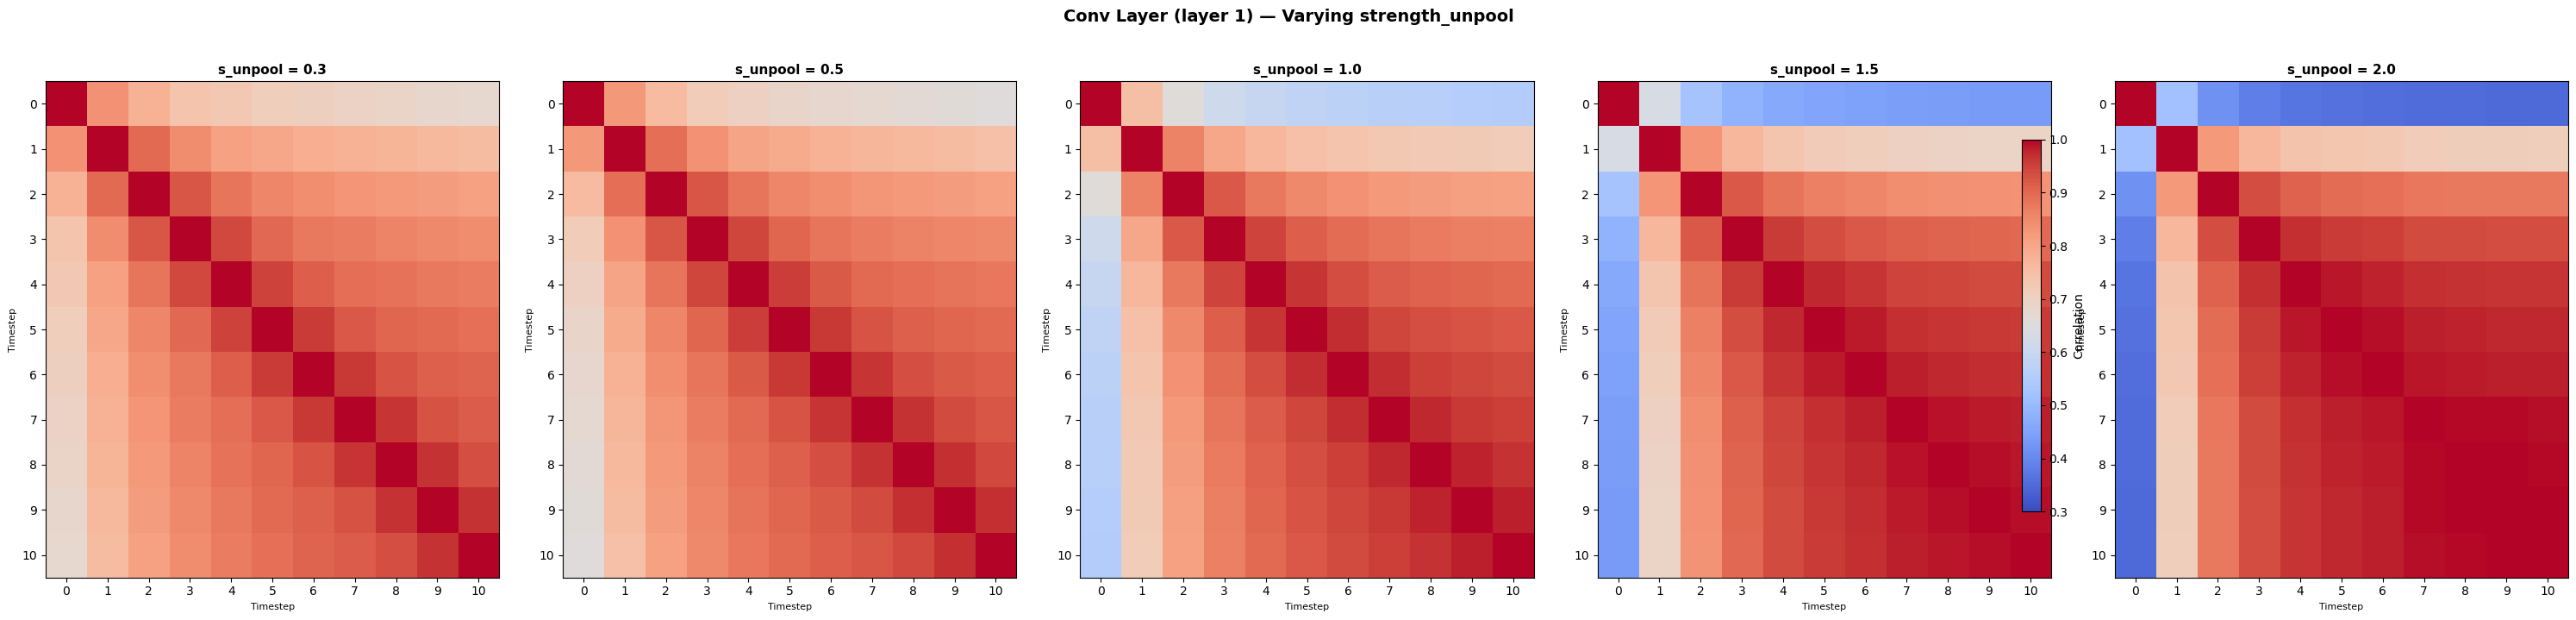

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_52318/2733256664.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


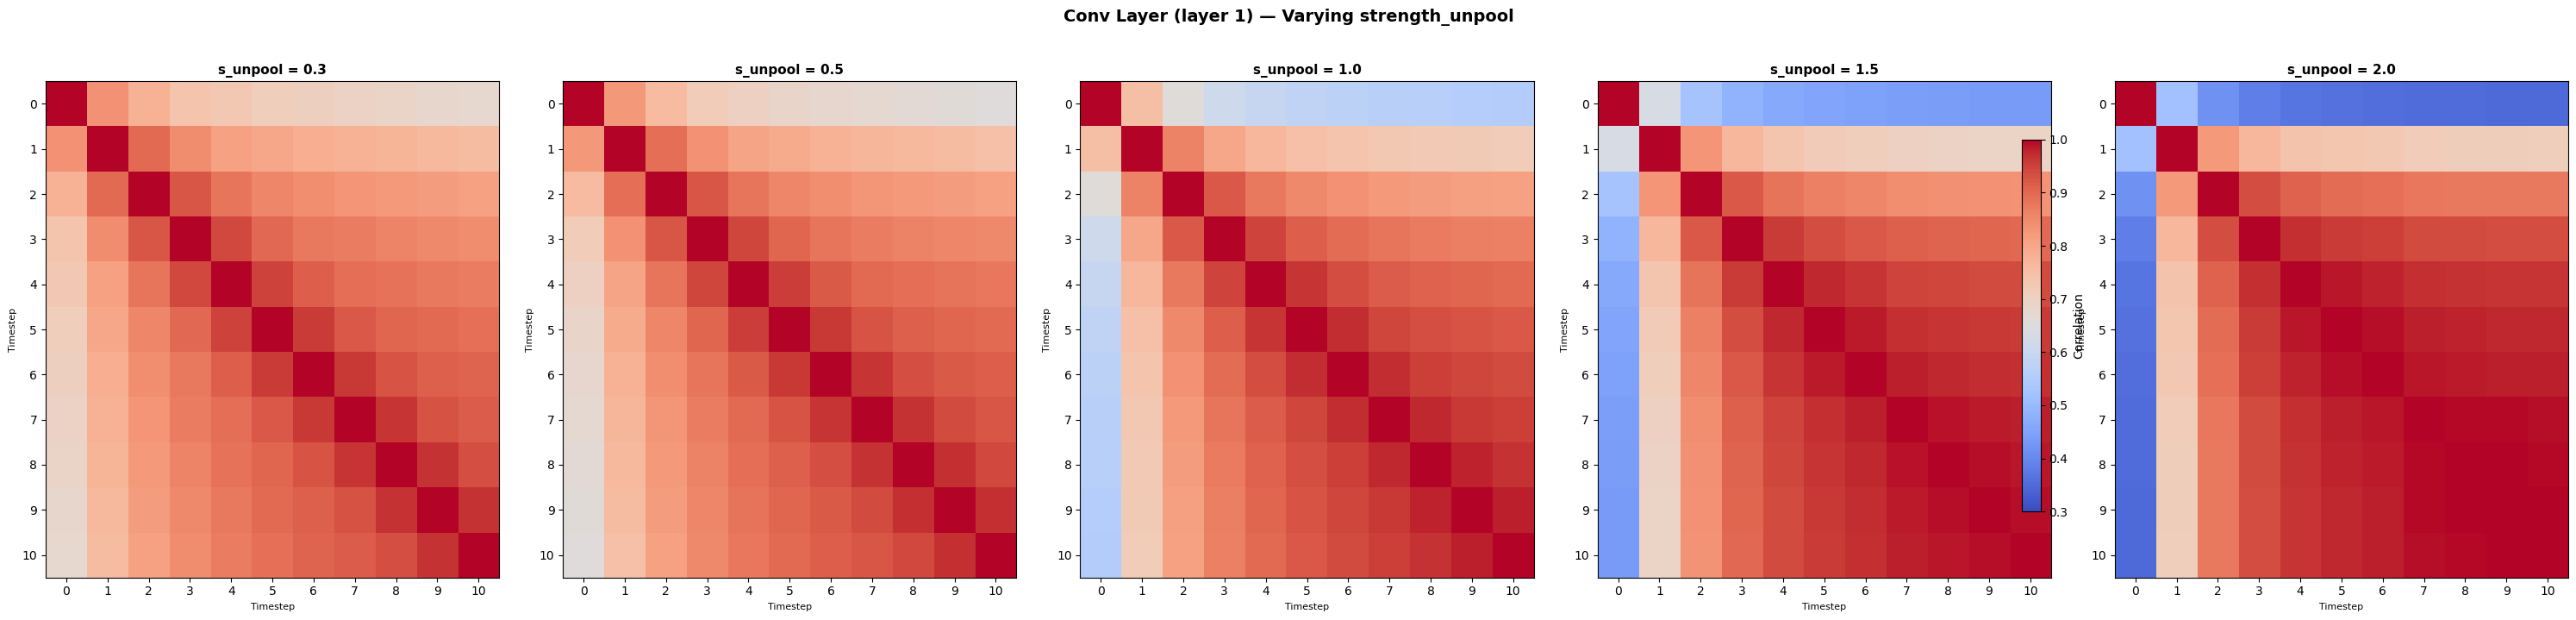

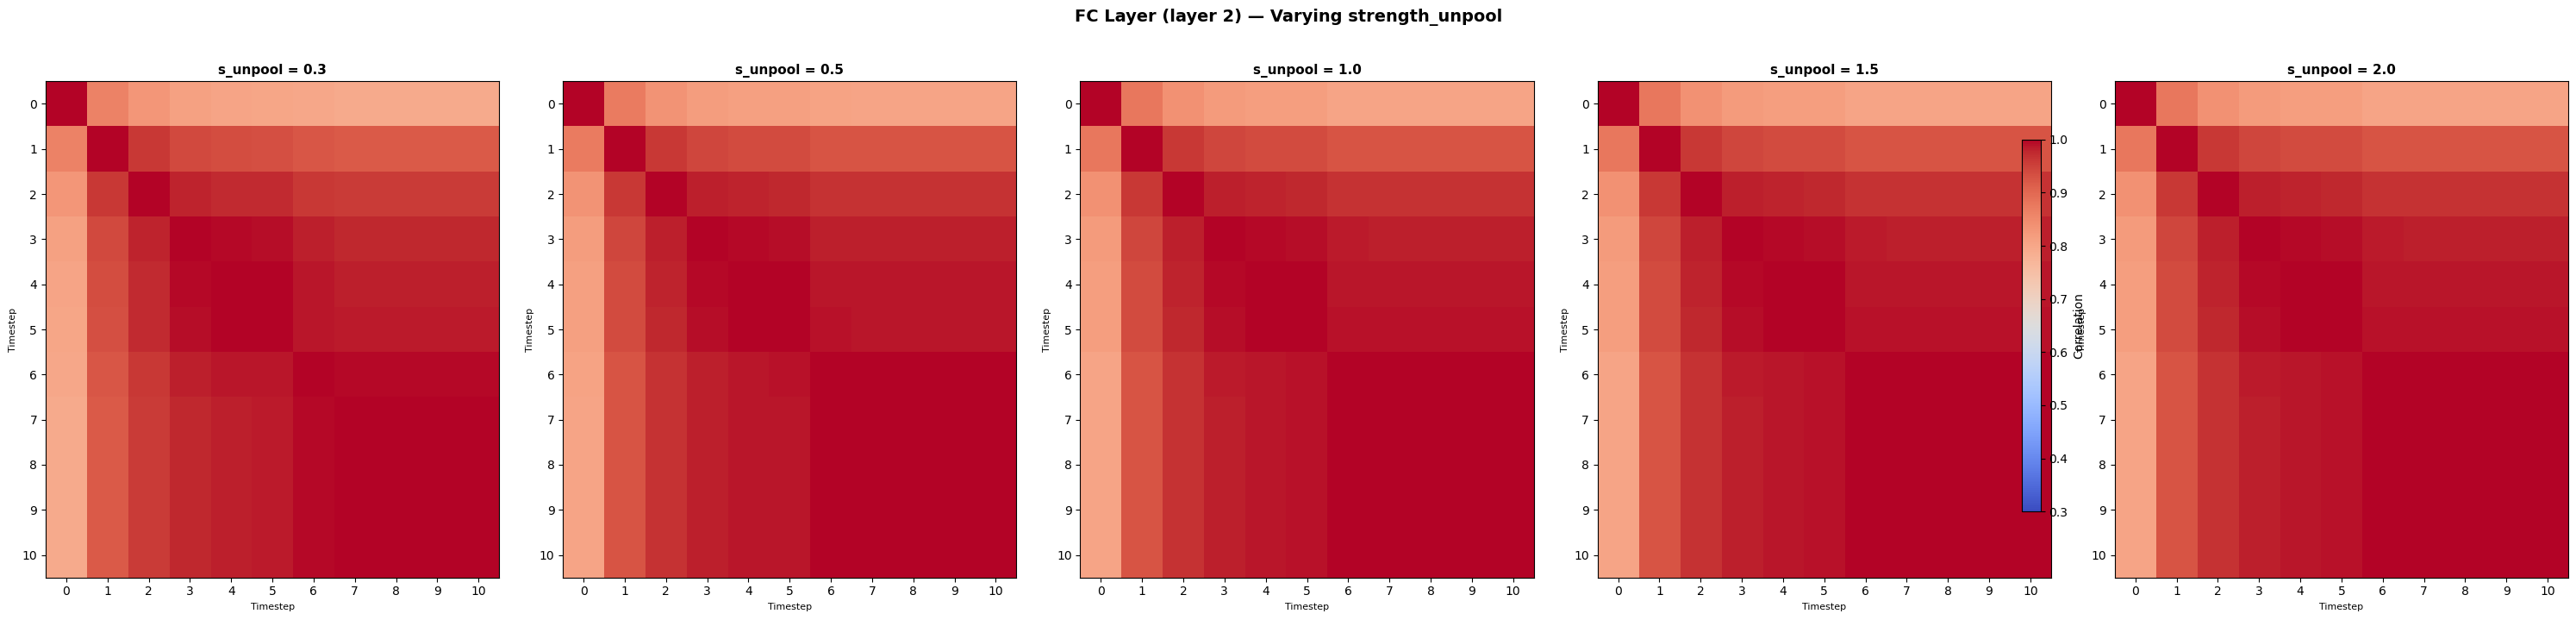

In [49]:
# ---- Sweep over strength_unpool (only) ----
strength_values = [0.3, 0.5, 1.0, 1.5, 2.0]
subtitles = [f"s_unpool = {s}" for s in strength_values]

corr_l1, corr_l2 = [], []
for s in strength_values:
    history = run_dynamics(x, y, strength_unpool=s)
    corr_l1.append(compute_cosine_similarity_matrix(history, layer_idx=1))
    corr_l2.append(compute_cosine_similarity_matrix(history, layer_idx=2))

plot_correlation_row(corr_l1, subtitles, suptitle="Conv Layer (layer 1) — Varying strength_unpool")
plot_correlation_row(corr_l2, subtitles, suptitle="FC Layer (layer 2) — Varying strength_unpool")

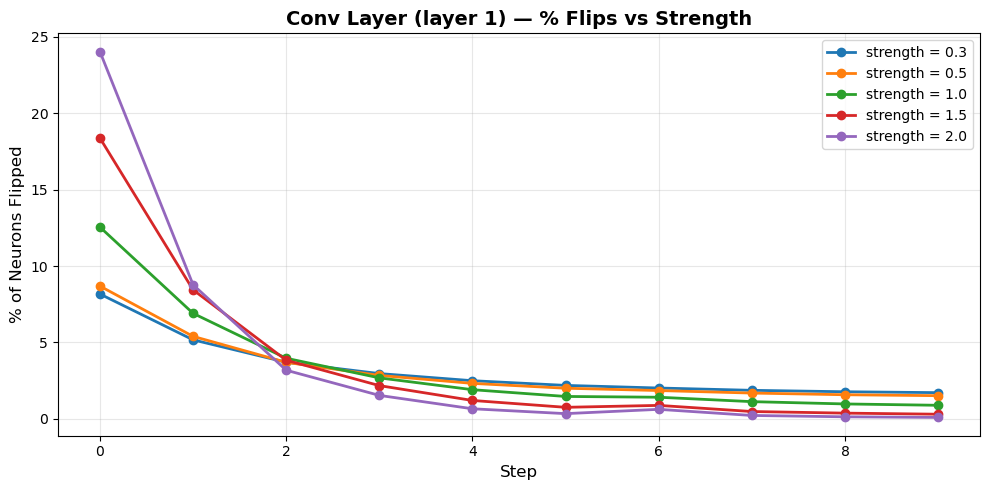

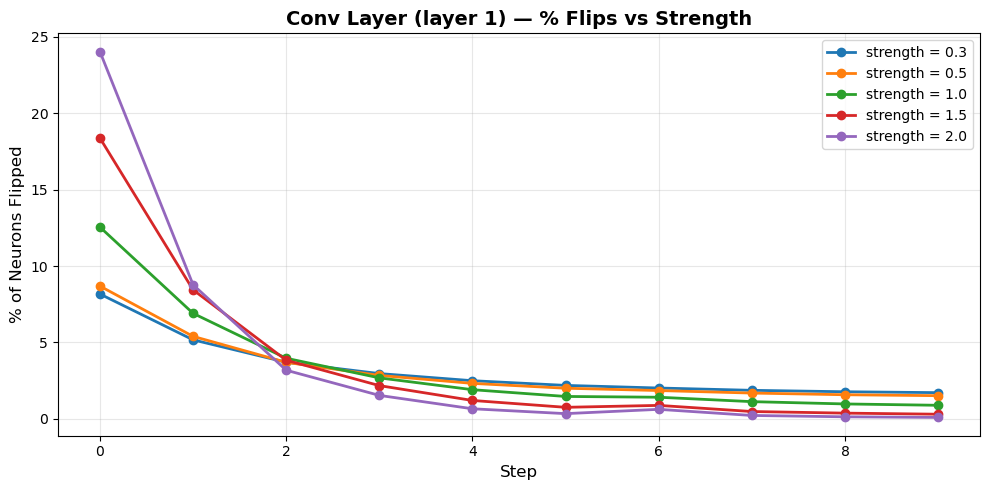

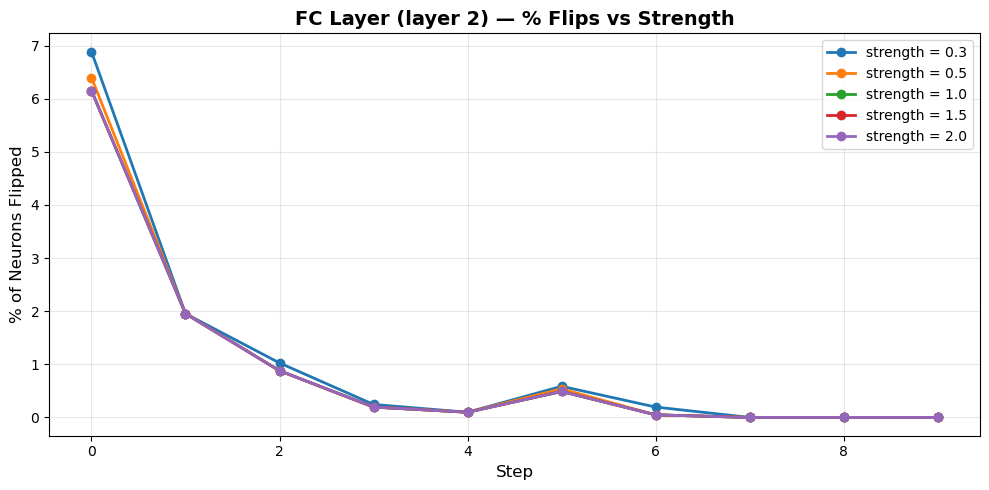

In [47]:
# ---- Neuron flips sweep over J_d ----
strength_values = [0.3, 0.5, 1.0, 1.5, 2.0]

# Conv layer (layer 1)
flips_jd_l1 = {}
for s in strength_values:
    history = run_dynamics(x, y, strength_unpool=s)
    flips_jd_l1[f"strength = {s}"] = compute_neuron_flips(history, layer_idx=1, percentage=True)

plot_neuron_flips(flips_jd_l1, title="Conv Layer (layer 1) — % Flips vs Strength", percentage=True)

# FC layer (layer 2)
flips_jd_l2 = {}
for s in strength_values:
    history = run_dynamics(x, y, strength_unpool=s)
    flips_jd_l2[f"strength = {s}"] = compute_neuron_flips(history, layer_idx=2, percentage=True)

plot_neuron_flips(flips_jd_l2, title="FC Layer (layer 2) — % Flips vs Strength", percentage=True)

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_52318/2733256664.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_52318/2733256664.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


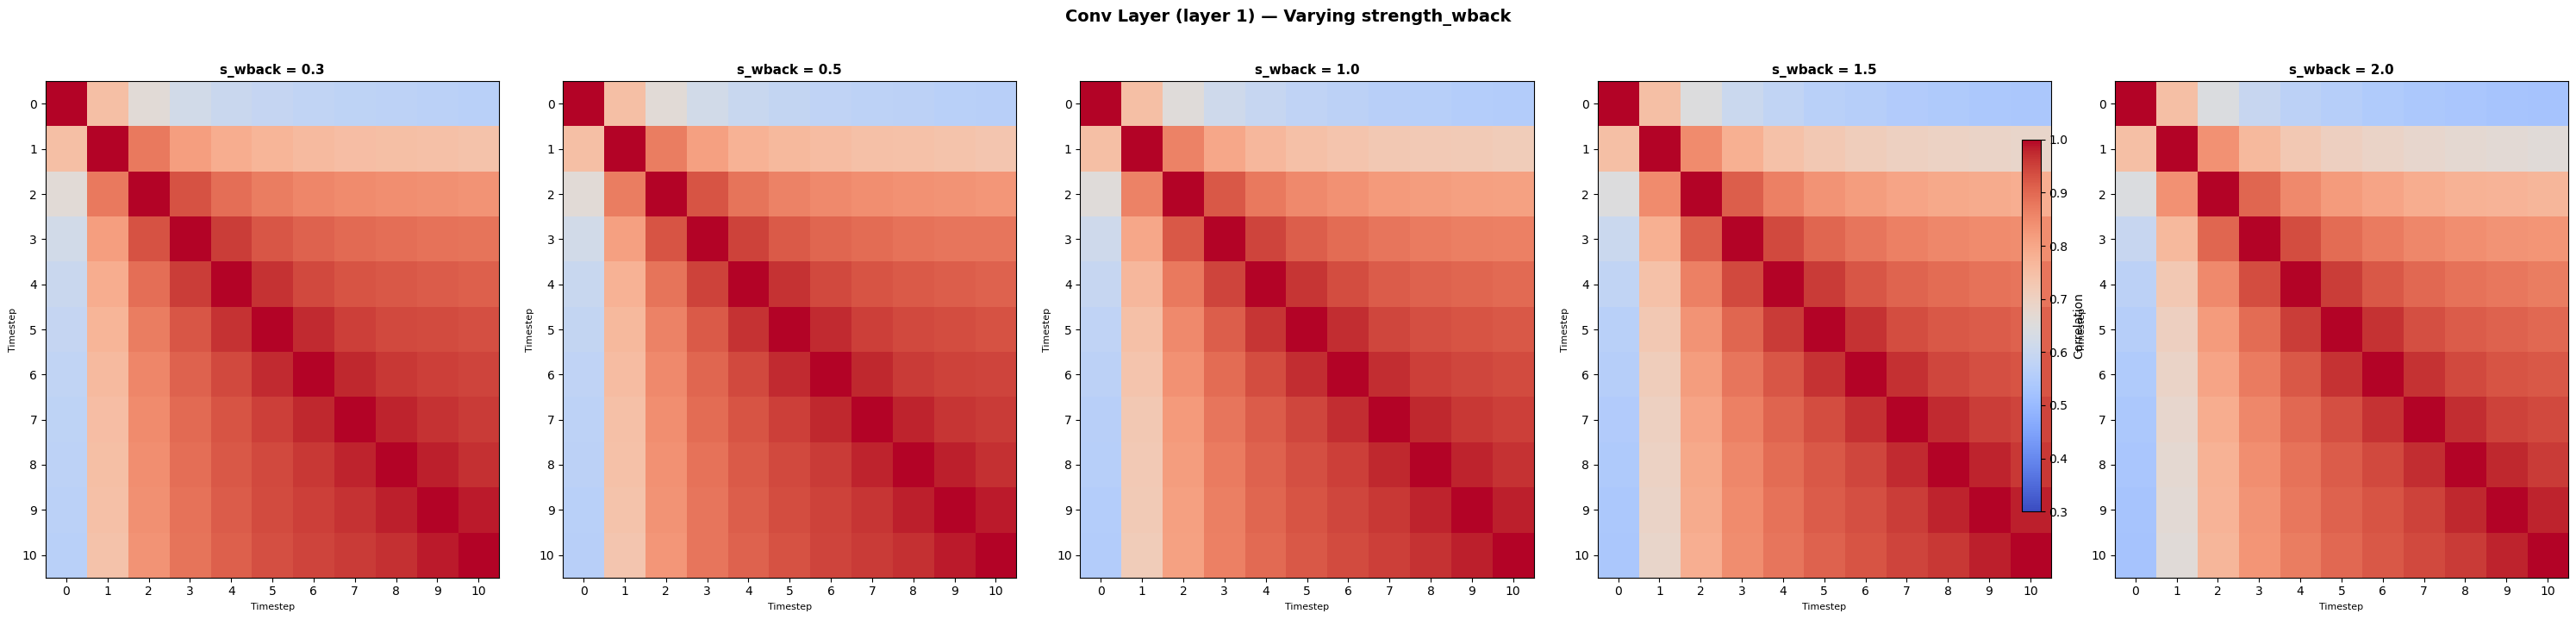

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_52318/2733256664.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


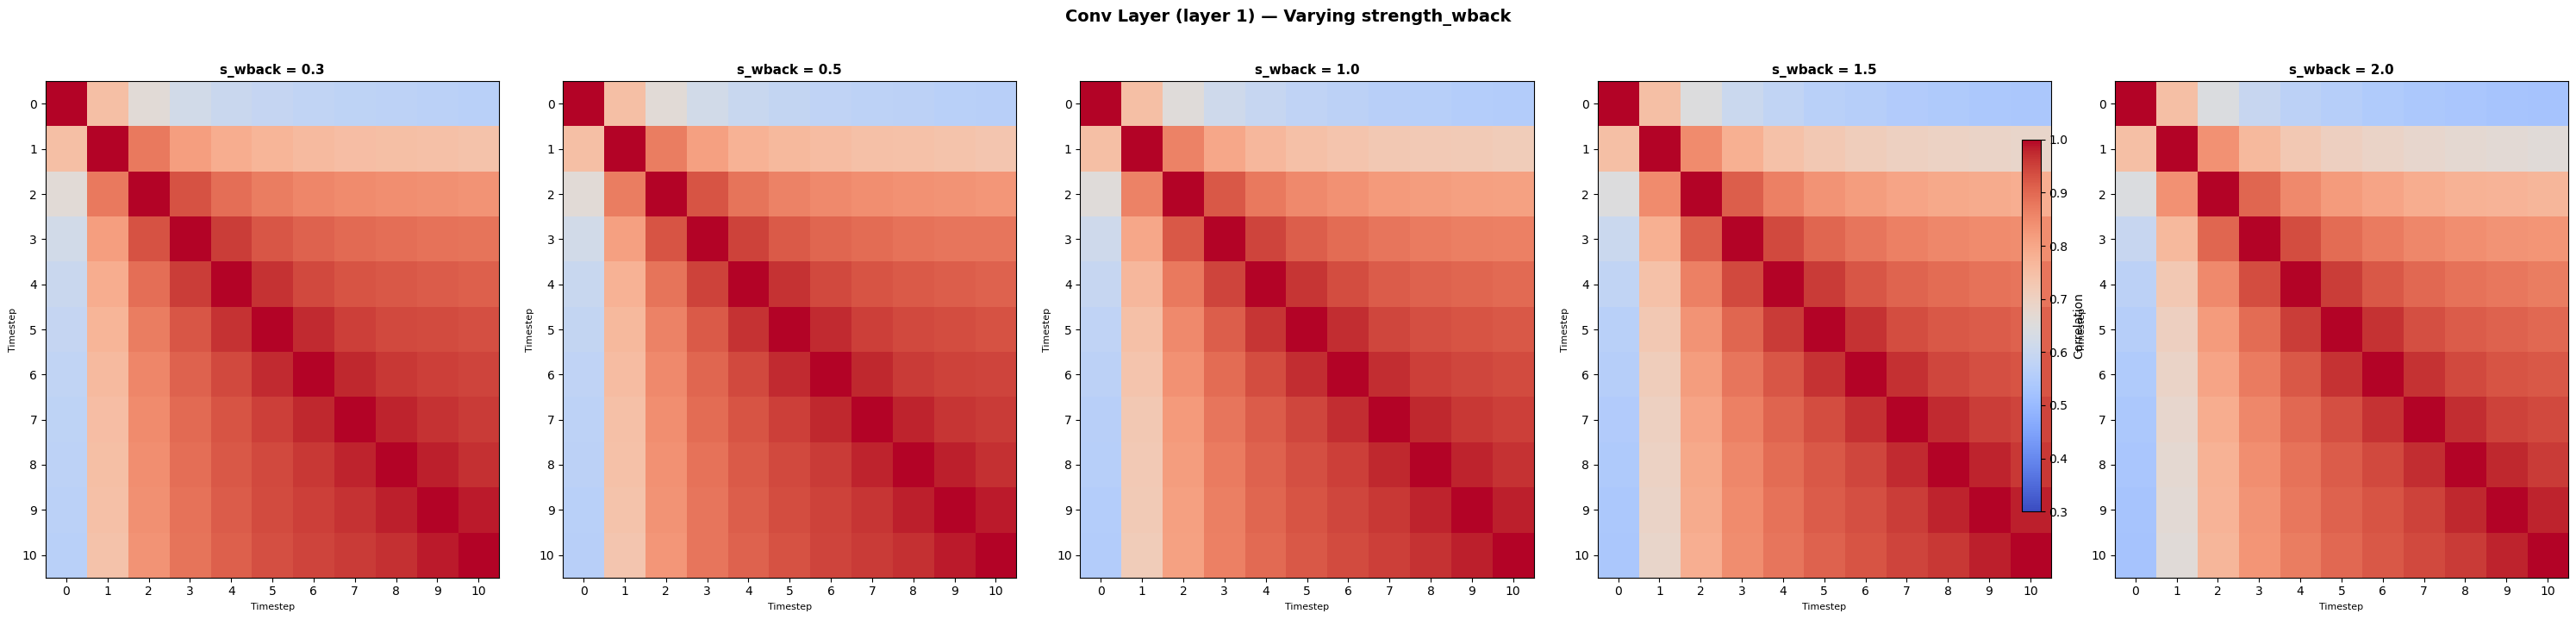

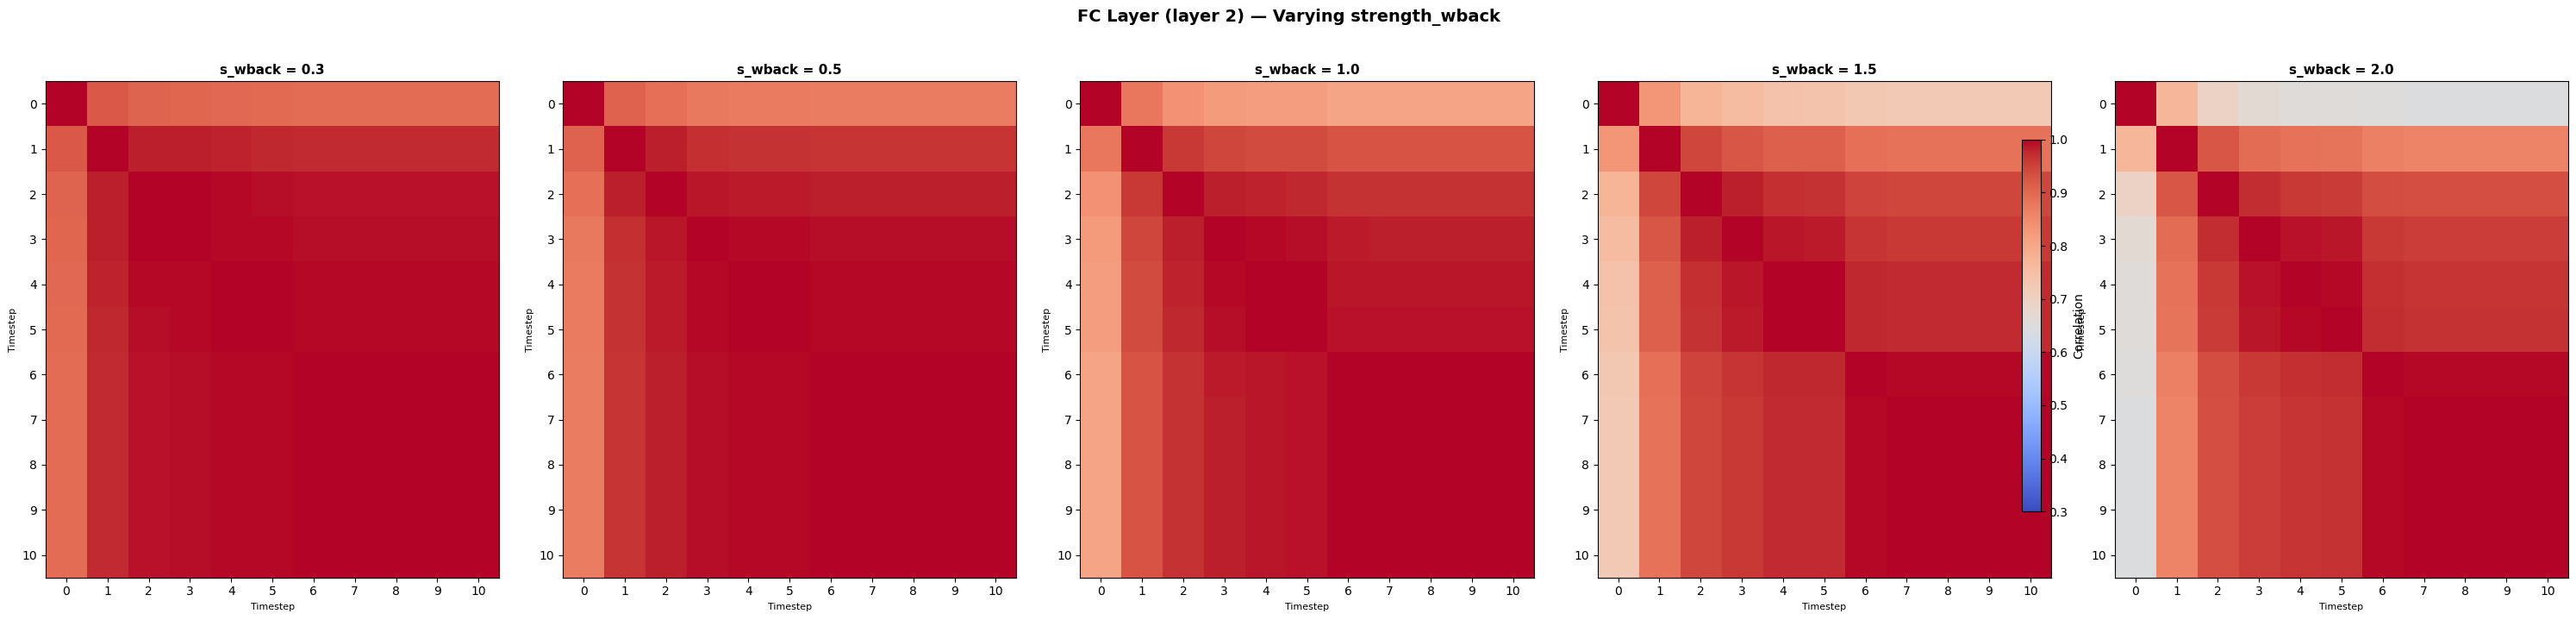

In [39]:
# ---- Sweep over strength_wback (only) ----
subtitles = [f"s_wback = {s}" for s in strength_values]

corr_l1, corr_l2 = [], []
for s in strength_values:
    history = run_dynamics(x, y, strength_wback=s)
    corr_l1.append(compute_cosine_similarity_matrix(history, layer_idx=1))
    corr_l2.append(compute_cosine_similarity_matrix(history, layer_idx=2))

plot_correlation_row(corr_l1, subtitles, suptitle="Conv Layer (layer 1) — Varying strength_wback")
plot_correlation_row(corr_l2, subtitles, suptitle="FC Layer (layer 2) — Varying strength_wback")

## Kernel Size Sweep

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_52318/2733256664.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


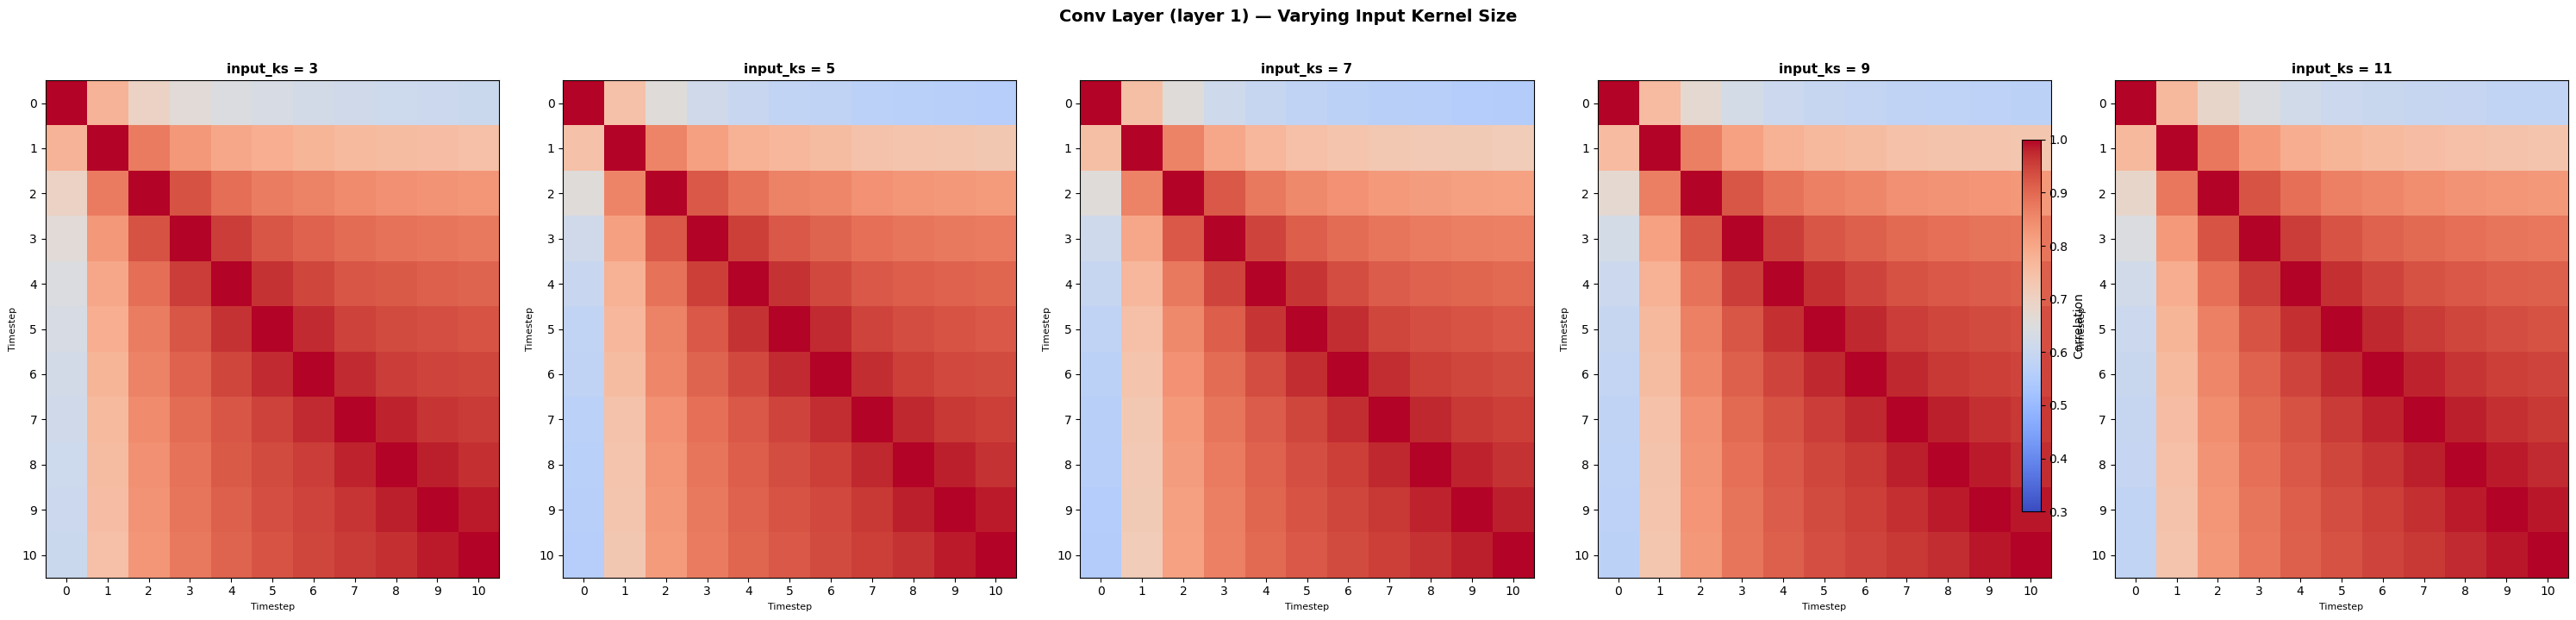

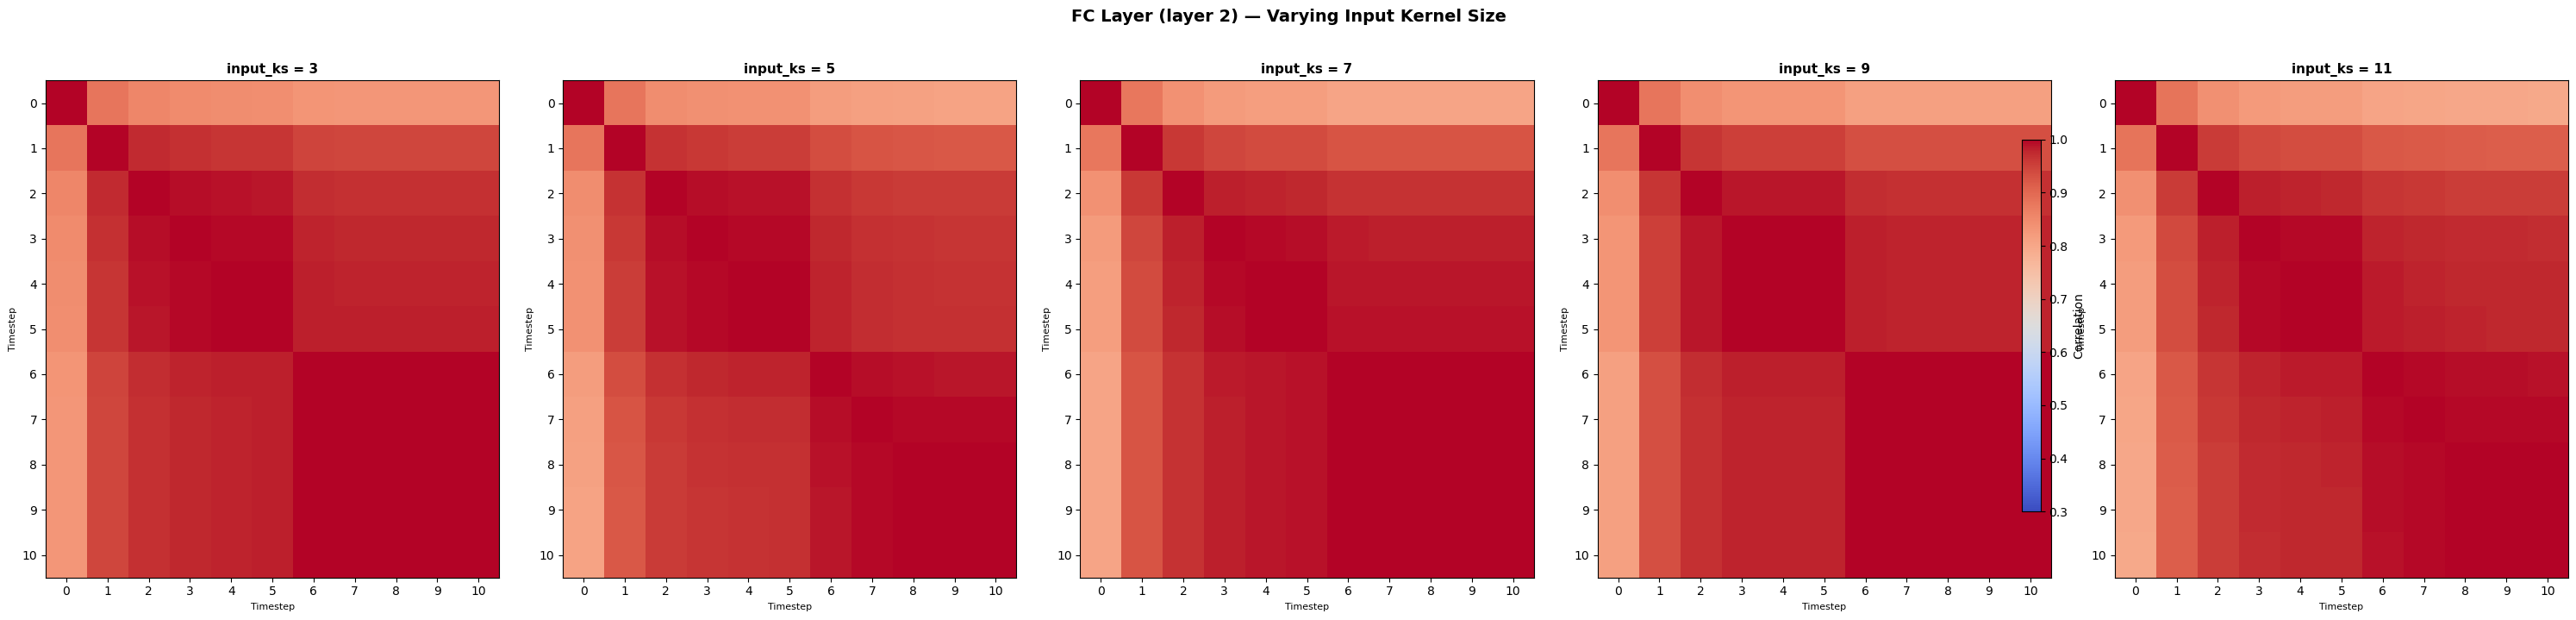

In [63]:
# ---- Sweep over INPUT_KERNEL_SIZE ----
input_ks_values = [3, 5, 7, 9, 11]
subtitles = [f"input_ks = {k}" for k in input_ks_values]

corr_l1, corr_l2 = [], []
for ks in input_ks_values:
    history = run_dynamics(x, y, INPUT_KERNEL_SIZE=ks)
    corr_l1.append(compute_cosine_similarity_matrix(history, layer_idx=1))
    corr_l2.append(compute_cosine_similarity_matrix(history, layer_idx=2))

plot_correlation_row(corr_l1, subtitles, suptitle="Conv Layer (layer 1) — Varying Input Kernel Size")
plot_correlation_row(corr_l2, subtitles, suptitle="FC Layer (layer 2) — Varying Input Kernel Size")

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_52318/2733256664.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


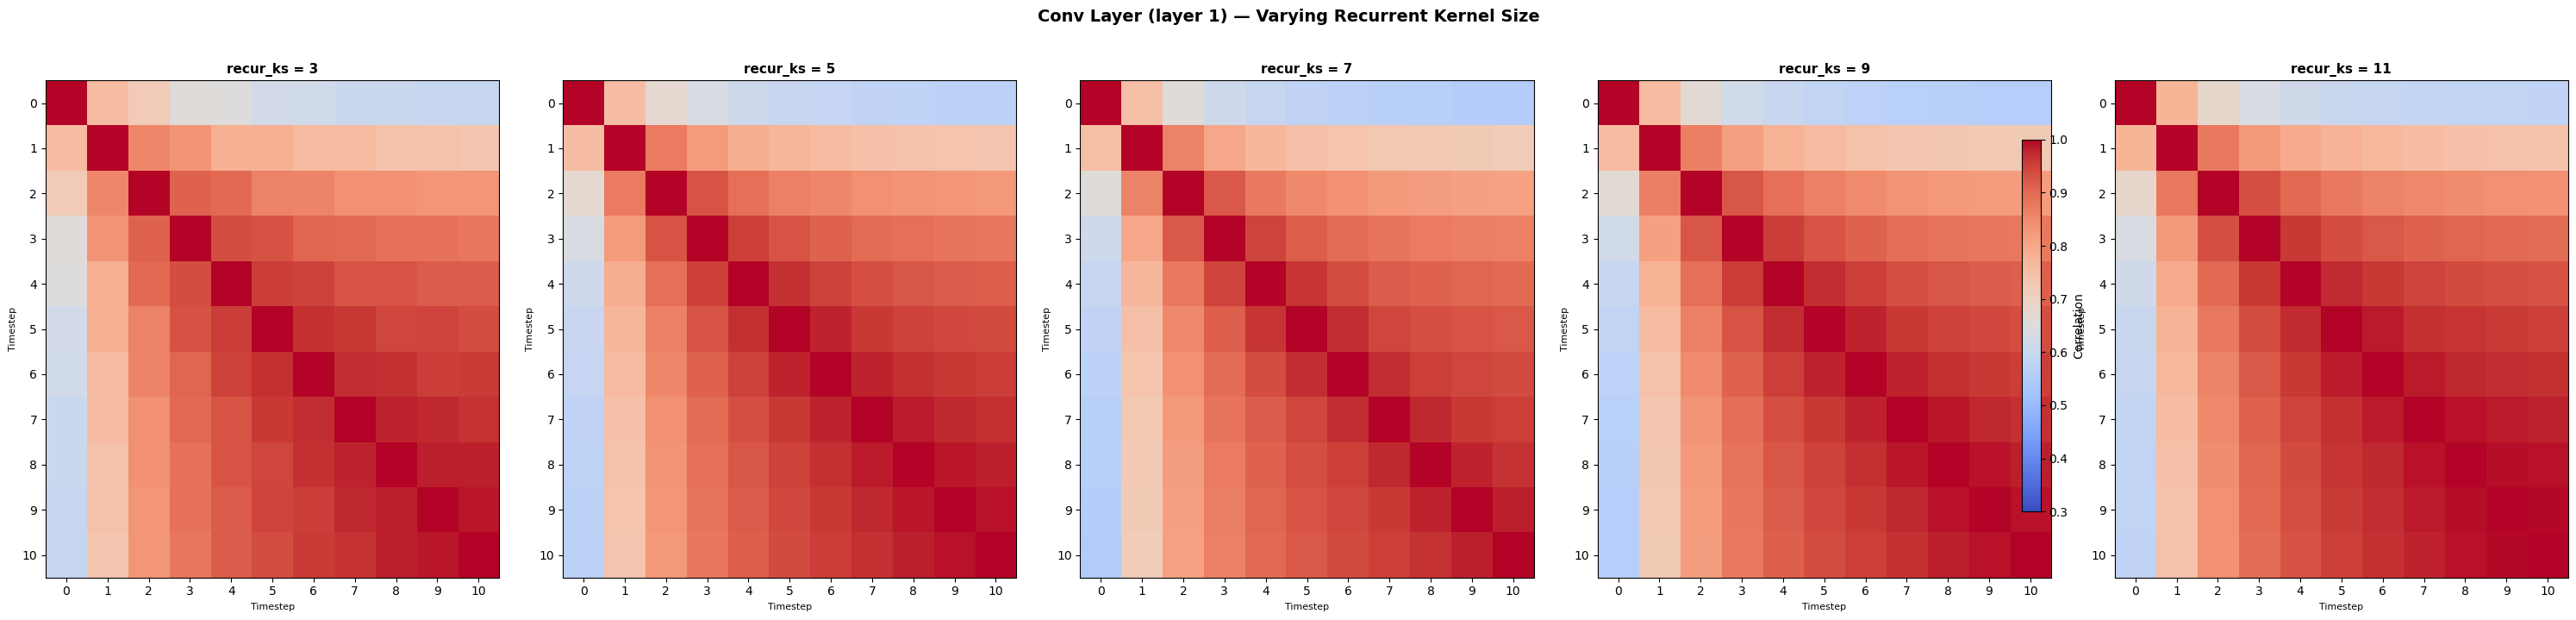

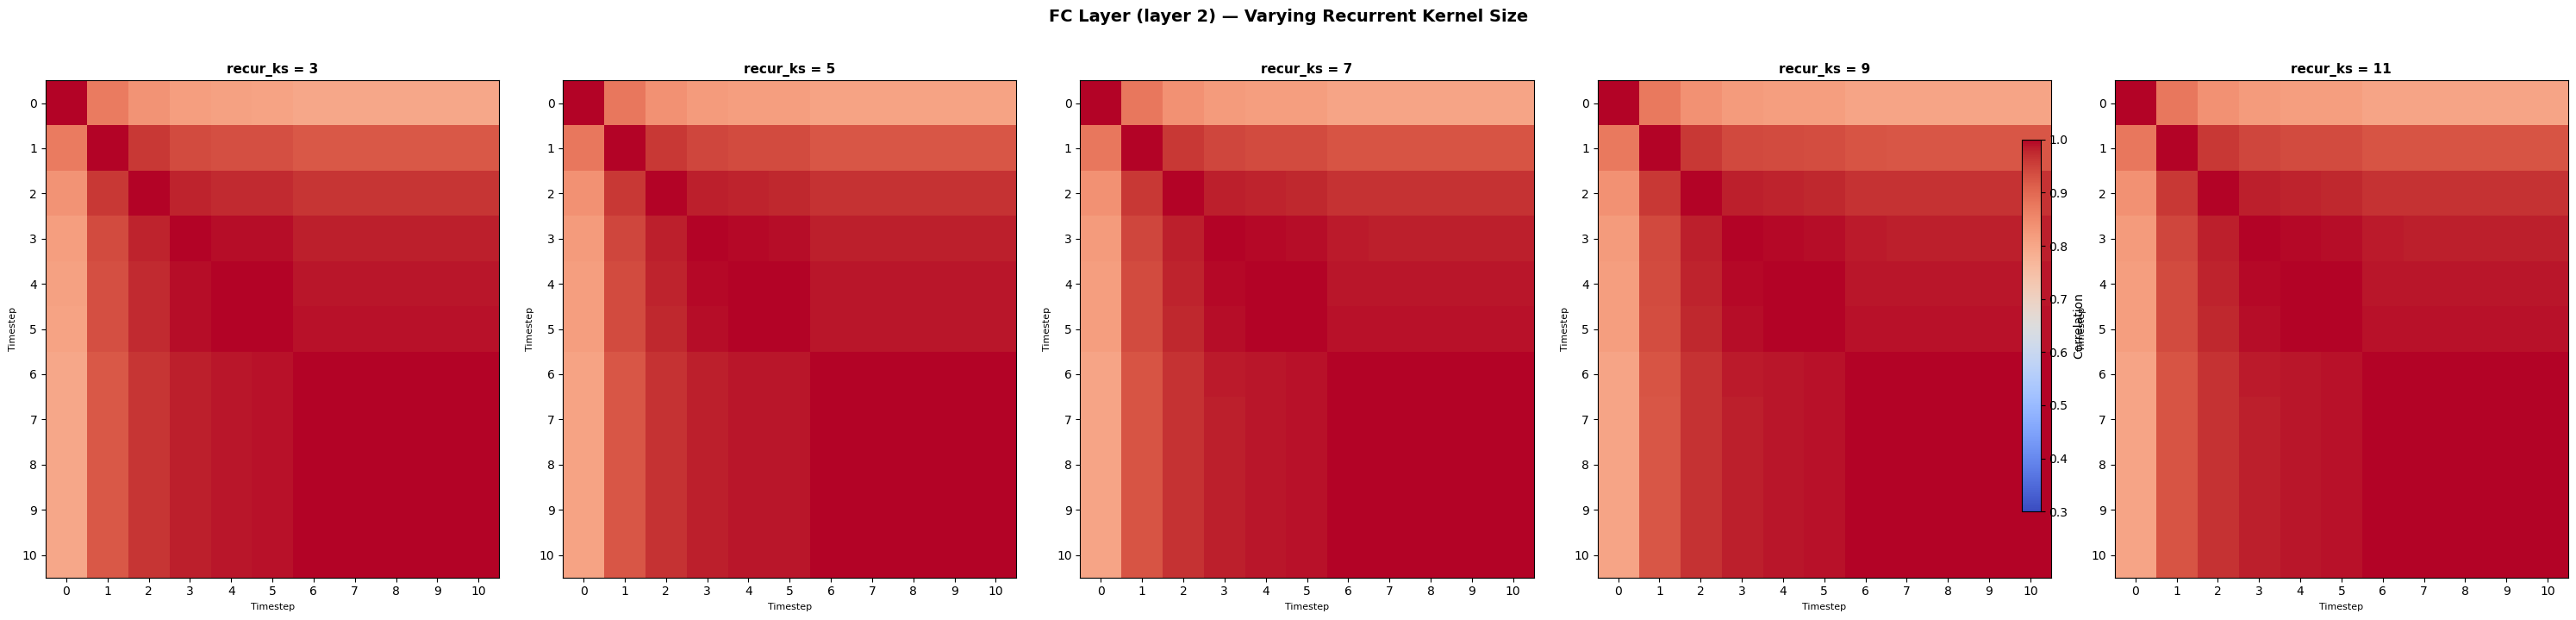

In [64]:
# ---- Sweep over RECUR_KERNEL_SIZE ----
recur_ks_values = [3, 5, 7, 9, 11]
subtitles = [f"recur_ks = {k}" for k in recur_ks_values]

corr_l1, corr_l2 = [], []
for ks in recur_ks_values:
    history = run_dynamics(x, y, RECUR_KERNEL_SIZE=ks)
    corr_l1.append(compute_cosine_similarity_matrix(history, layer_idx=1))
    corr_l2.append(compute_cosine_similarity_matrix(history, layer_idx=2))

plot_correlation_row(corr_l1, subtitles, suptitle="Conv Layer (layer 1) — Varying Recurrent Kernel Size")
plot_correlation_row(corr_l2, subtitles, suptitle="FC Layer (layer 2) — Varying Recurrent Kernel Size")

## W_back Overlap Analysis

In [42]:
def compute_wback_overlap(states_history, wback_module, layer_idx=2, output_idx=3, batch_idx=None):
    """
    At each timestep, compute cosine similarity between:
      - W_back(output): the label signal projected into layer 2's space
      - states[layer_idx]: the actual state of layer 2
    
    Returns
    -------
    overlaps : array of shape (n_timesteps,)
    """
    n_timesteps = len(states_history)
    overlaps = np.zeros(n_timesteps)
    
    for t in range(n_timesteps):
        output = states_history[t].states[output_idx]        # (batch, 10)
        projected = np.array(wback_module(output))            # (batch, N_CHANNELS)
        layer2 = np.array(states_history[t].states[layer_idx]) # (batch, N_CHANNELS)
        
        if batch_idx is not None:
            p, l = projected[batch_idx], layer2[batch_idx]
            dot = np.dot(p, l)
            overlaps[t] = dot / (np.linalg.norm(p) * np.linalg.norm(l) + 1e-8)
        else:
            cos_sims = []
            for b in range(layer2.shape[0]):
                p, l = projected[b], layer2[b]
                dot = np.dot(p, l)
                cos_sims.append(dot / (np.linalg.norm(p) * np.linalg.norm(l) + 1e-8))
            overlaps[t] = np.mean(cos_sims)
    
    return overlaps


def plot_wback_overlap(overlaps_dict, n_warmup=1, n_clamped=5, title="W_back Overlap with Layer 2", figsize=(10, 5)):
    """
    Plot overlap over time, with shaded regions for warmup / clamped / free phases.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    if isinstance(overlaps_dict, dict):
        n_steps = len(list(overlaps_dict.values())[0])
        for label, ov in overlaps_dict.items():
            ax.plot(range(len(ov)), ov, marker='o', label=label, linewidth=2)
        ax.legend()
    else:
        n_steps = len(overlaps_dict)
        ax.plot(range(n_steps), overlaps_dict, marker='o', linewidth=2, color='blue')
    
    # Shade phases
    ax.axvspan(-0.5, n_warmup - 0.5, alpha=0.1, color='blue', label='warmup')
    ax.axvspan(n_warmup - 0.5, n_warmup + n_clamped - 0.5, alpha=0.1, color='green', label='clamped')
    ax.axvspan(n_warmup + n_clamped - 0.5, n_steps - 0.5, alpha=0.1, color='red', label='free')
    
    ax.set_xlabel('Step', fontsize=12)
    ax.set_ylabel('Cosine Similarity', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

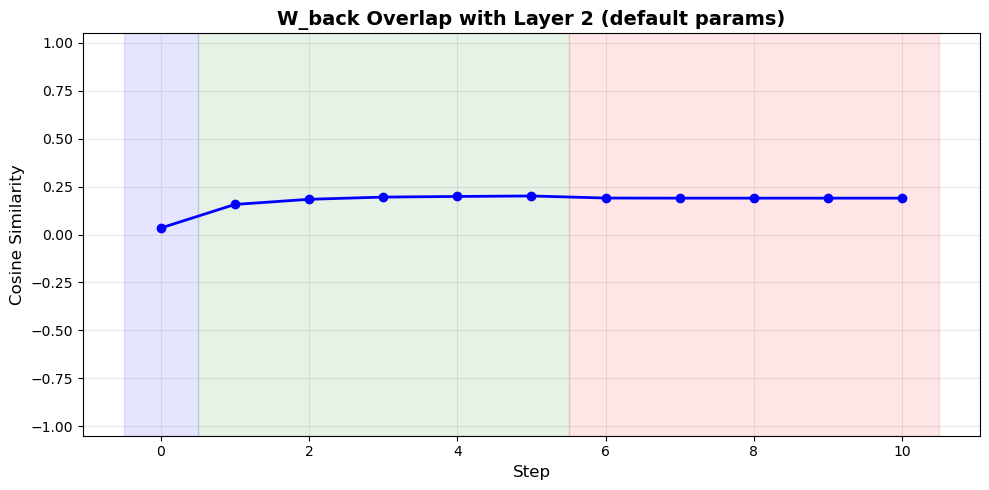

In [43]:
# Build the same wback used in run_dynamics (same seed=42 → same weights)
keys_test = jax.random.split(jax.random.PRNGKey(42), 5)
_wback_default = FrozenRescaledFullyConnected(
    in_features=10, out_features=64,
    strength=1.0, threshold=0.0, key=keys_test[4],
)

# Run dynamics with default params and compute overlap
history = run_dynamics(x, y)
overlaps = compute_wback_overlap(history, _wback_default)
plot_wback_overlap(overlaps, title="W_back Overlap with Layer 2 (default params)")

## Comprehensive W_back Overlap Experiments

Analyze how all key parameters affect the W_back overlap with layer 2.


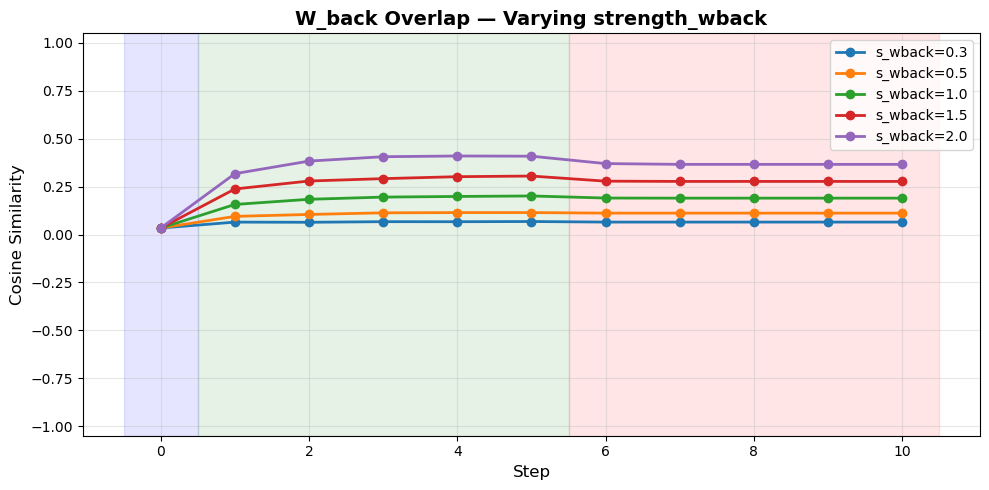

In [65]:
# ---- W_back overlap: strength_wback sweep ----
strength_wback_values = [0.3, 0.5, 1.0, 1.5, 2.0]

overlap_swback = {}
for s_wb in strength_wback_values:
    keys_test = jax.random.split(jax.random.PRNGKey(42), 5)
    _wb = FrozenRescaledFullyConnected(
        in_features=10, out_features=64,
        strength=s_wb, threshold=0.0, key=keys_test[4],
    )
    history = run_dynamics(x, y, strength_wback=s_wb)
    overlap_swback[f"s_wback={s_wb}"] = compute_wback_overlap(history, _wb)

plot_wback_overlap(overlap_swback, title="W_back Overlap — Varying strength_wback")


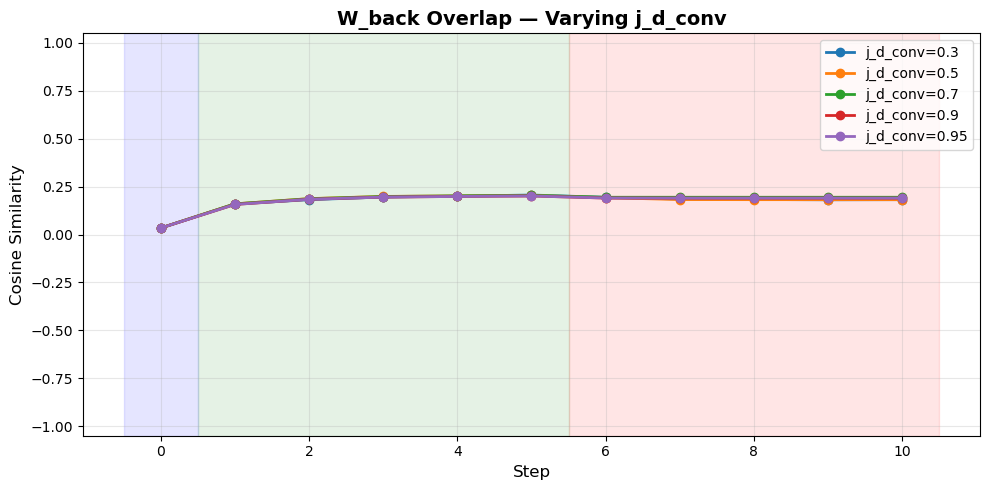

In [66]:
# ---- W_back overlap: J_d_conv sweep ----
j_d_conv_values = [0.3, 0.5, 0.7, 0.9, 0.95]

overlap_jdc = {}
keys_test = jax.random.split(jax.random.PRNGKey(42), 5)
_wb_default = FrozenRescaledFullyConnected(
    in_features=10, out_features=64,
    strength=1.0, threshold=0.0, key=keys_test[4],
)

for j_d_c in j_d_conv_values:
    history = run_dynamics(x, y, j_d_conv=j_d_c)
    overlap_jdc[f"j_d_conv={j_d_c}"] = compute_wback_overlap(history, _wb_default)

plot_wback_overlap(overlap_jdc, title="W_back Overlap — Varying j_d_conv")


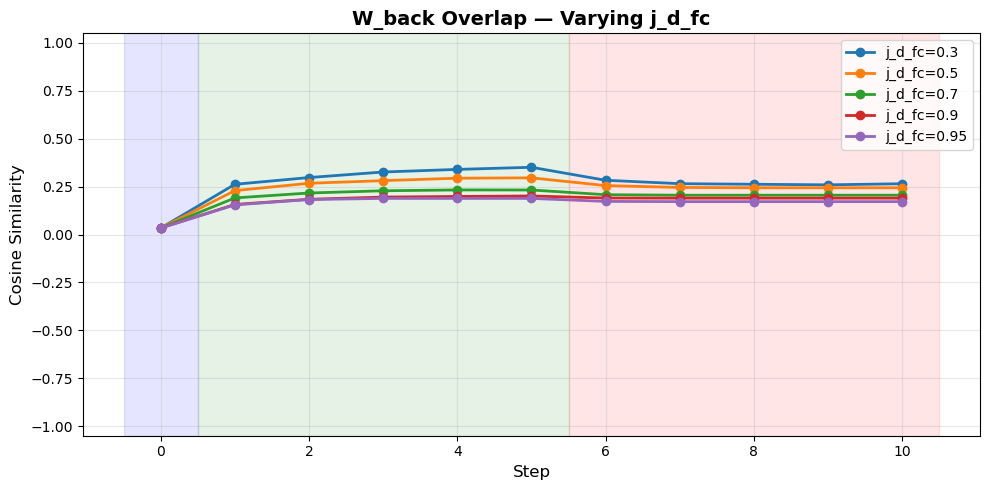

In [67]:
# ---- W_back overlap: J_d_fc sweep ----
j_d_fc_values = [0.3, 0.5, 0.7, 0.9, 0.95]

overlap_jdfc = {}
for j_d_f in j_d_fc_values:
    history = run_dynamics(x, y, j_d_fc=j_d_f)
    overlap_jdfc[f"j_d_fc={j_d_f}"] = compute_wback_overlap(history, _wb_default)

plot_wback_overlap(overlap_jdfc, title="W_back Overlap — Varying j_d_fc")


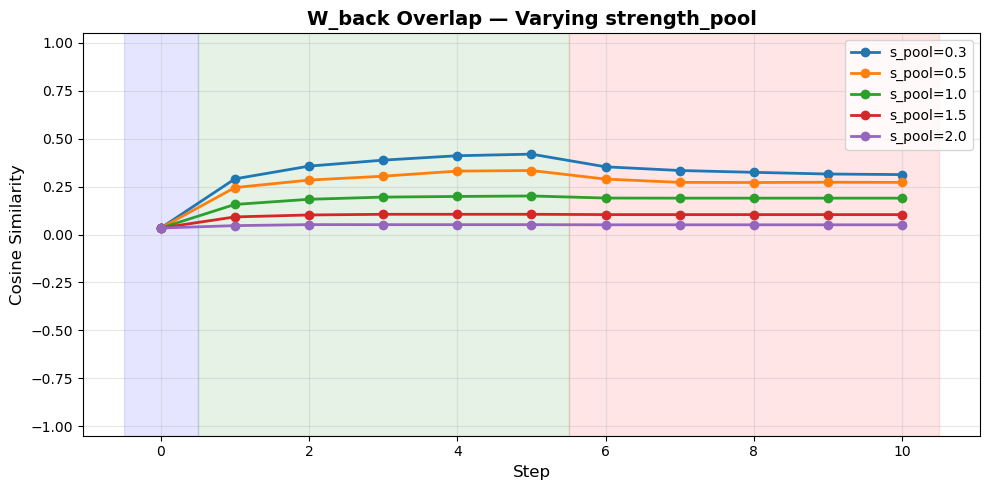

In [68]:
# ---- W_back overlap: strength_pool sweep ----
strength_pool_values = [0.3, 0.5, 1.0, 1.5, 2.0]

overlap_spool = {}
for s_p in strength_pool_values:
    history = run_dynamics(x, y, strength_pool=s_p)
    overlap_spool[f"s_pool={s_p}"] = compute_wback_overlap(history, _wb_default)

plot_wback_overlap(overlap_spool, title="W_back Overlap — Varying strength_pool")


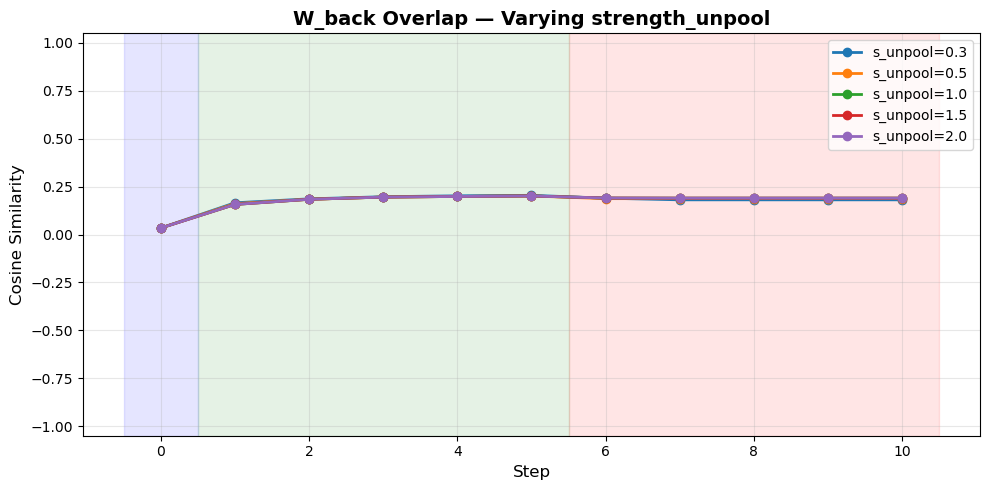

In [69]:
# ---- W_back overlap: strength_unpool sweep ----
strength_unpool_values = [0.3, 0.5, 1.0, 1.5, 2.0]

overlap_sunpool = {}
for s_up in strength_unpool_values:
    history = run_dynamics(x, y, strength_unpool=s_up)
    overlap_sunpool[f"s_unpool={s_up}"] = compute_wback_overlap(history, _wb_default)

plot_wback_overlap(overlap_sunpool, title="W_back Overlap — Varying strength_unpool")


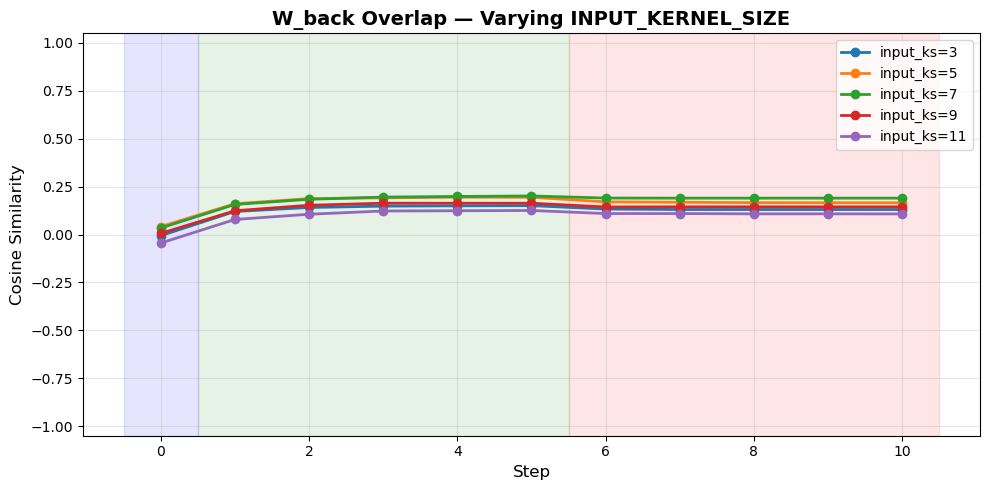

In [70]:
# ---- W_back overlap: INPUT_KERNEL_SIZE sweep ----
input_ks_values = [3, 5, 7, 9, 11]

overlap_input_ks = {}
for iks in input_ks_values:
    history = run_dynamics(x, y, INPUT_KERNEL_SIZE=iks)
    overlap_input_ks[f"input_ks={iks}"] = compute_wback_overlap(history, _wb_default)

plot_wback_overlap(overlap_input_ks, title="W_back Overlap — Varying INPUT_KERNEL_SIZE")


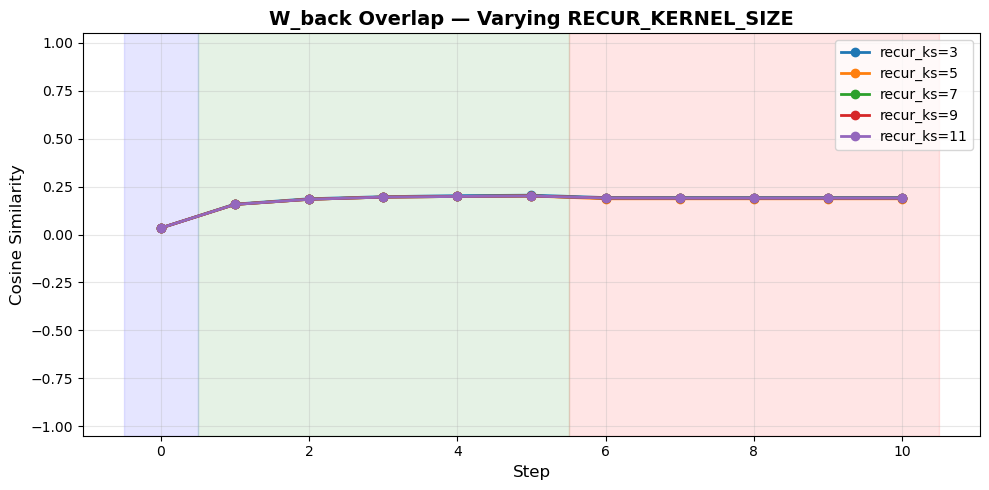

In [71]:
# ---- W_back overlap: RECUR_KERNEL_SIZE sweep ----
recur_ks_values = [3, 5, 7, 9, 11]

overlap_recur_ks = {}
for rks in recur_ks_values:
    history = run_dynamics(x, y, RECUR_KERNEL_SIZE=rks)
    overlap_recur_ks[f"recur_ks={rks}"] = compute_wback_overlap(history, _wb_default)

plot_wback_overlap(overlap_recur_ks, title="W_back Overlap — Varying RECUR_KERNEL_SIZE")
